# Fashion E-Commerce


---
## Load data

In [ ]:
import duckdb
import pandas as pd

customers   = pd.read_excel("customers.xlsx",   dtype=str)
products    = pd.read_excel("products.xlsx",    dtype=str)
order_lines = pd.read_excel("order_lines.xlsx", dtype=str)

print("customers  ", customers.shape)
print("products   ", products.shape)
print("order_lines", order_lines.shape)


customers   (1056, 7)
products    (108, 8)
order_lines (4630, 12)


In [ ]:
customers.head(5)

,customer_id,registration_date,first_purchase_date,city,customer_acquisition_source,customer_status,marketing_consent
0,CUS10001,2025-08-05 00:00:00,2026-01-10 00:00:00,Surabaya,Organic Search,Inactive,Yes
1,CUS10002,2024-08-04 00:00:00,2024-10-10 00:00:00,Bandung,Direct,Active,Yes
2,CUS10003,2025-02-22 00:00:00,2025-06-17 00:00:00,Jakarta,Direct,Active,No
3,CUS10004,2025-12-20 00:00:00,2026-04-15 00:00:00,Semarang,Organic Search,Inactive,Yes
4,CUS10005,2025-11-08 00:00:00,2025-12-28 00:00:00,Yogyakarta,Paid Search,Active,Yes


In [ ]:
products.head(5)

,product_id,product_name,category,brand,launch_date,list_price,product_status,size_required
0,PRD1001,Handbags Mirela 23,Handbags,Mirela,2023-05-17 00:00:00,3132000,Active,No
1,PRD1002,Handbags ELOVA 21,Handbags,ELOVA,2025-04-24 00:00:00,3288000,Active,No
2,PRD1003,Handbags Mirela 99,Handbags,Mirela,2025-02-23 00:00:00,1367000,Active,No
3,PRD1004,Handbags Luria 30,Handbags,Luria,2023-07-24 00:00:00,2736000,Active,No
4,PRD1005,Handbags Cantera 58,Handbags,Cantera,2023-03-17 00:00:00,3378000,Active,No


In [ ]:
order_lines.head(5)

,order_line_id,order_id,order_date,customer_id,product_id,sales_channel,traffic_source,quantity,unit_selling_price,discount_amount,order_status,payment_method
0,OL104570,ORD22711,2026-05-25 00:00:00,CUS11033,PRD1075,Marketplace,Marketplace,1,515000,1000,Completed,credit_card
1,OL103139,ORD21883,2026-03-26 00:00:00,CUS10355,PRD1104,Website,Paid Social,1,437000,5000,Completed,Bank Transfer
2,OL103874,ORD22323,2026-06-02 00:00:00,CUS10362,PRD1065,Marketplace,Marketplace,1,1361000,103000,Completed,GoPay
3,OL101598,ORD20978,2026-05-30 00:00:00,CUS10399,PRD1008,Website,Direct,1,4353000,94000,Completed,Bank Transfer
4,OL102190,ORD21310,2026-03-29 00:00:00,CUS10702,PRD1046,Marketplace,Marketplace,1,1129000,52000,Completed,Bank Transfer


# Deskripsi Kolom

## 1. `customers` — 1.056 baris × 7 kolom

| Kolom | Deskripsi |
|---|---|
| `customer_id` | Identitas unik customer |
| `registration_date` | Tanggal customer mendaftar akun |
| `first_purchase_date` | Tanggal pembelian pertama customer, sepanjang sejarah |
| `city` | Kota domisili customer |
| `customer_acquisition_source` | Kanal yang pertama kali mendatangkan customer ini |
| `customer_status` | Status akun customer |
| `marketing_consent` | Izin customer menerima materi pemasaran |

## 2. `products` — 108 baris × 8 kolom

| Kolom | Deskripsi |
|---|---|
| `product_id` | Identitas unik produk |
| `product_name` | Nama produk |
| `category` | Kategori produk |
| `brand` | Merek produk |
| `launch_date` | Tanggal produk mulai dijual |
| `list_price` | Harga daftar produk |
| `product_status` | Status produk di katalog |
| `size_required` | Apakah produk memerlukan pilihan ukuran |

## 3. `order_lines` — 4.630 baris × 12 kolom

| Kolom | Deskripsi |
|---|---|
| `order_line_id` | Identitas unik baris order |
| `order_id` | Identitas order; satu order dapat memuat beberapa baris |
| `order_date` | Tanggal order dibuat |
| `customer_id` | Rujukan ke customer yang melakukan order |
| `product_id` | Rujukan ke produk yang dibeli pada baris ini |
| `sales_channel` | Kanal penjualan tempat order terjadi |
| `traffic_source` | Sumber trafik yang mengantar ke order ini |
| `quantity` | Jumlah unit produk pada baris ini |
| `unit_selling_price` | Harga jual per unit, sebelum diskon |
| `discount_amount` | Nilai diskon pada baris ini, dalam Rupiah |
| `order_status` | Status penyelesaian order |
| `payment_method` | Metode pembayaran yang digunakan |

In [ ]:
# Bukti bahwa SQL bisa langsung membaca variabel pandas
duckdb.sql("SELECT sales_channel, COUNT(*) AS n FROM order_lines GROUP BY 1").df()

,sales_channel,n
0,Website,2720
1,Marketplace,1910


---
## Profiling


### Penjelasan Fungsi Profiling Data

Fungsi `profil()` dalam codingan ini digunakan untuk melakukan pemeriksaan kualitas data secara otomatis pada DataFrame Pandas. Berikut adalah poin-poin penjelasannya:

1.  **Deteksi Sifat Kolom (Heuristic Type Detection):**
    *   Meskipun data dibaca sebagai string, fungsi ini mencoba mengubah isi kolom menjadi angka atau tanggal.
    *   Jika >95% data berhasil diubah, kolom tersebut akan dikategorikan sebagai `angka` atau `tanggal` untuk memberikan ringkasan statistik yang relevan.

2.  **Identifikasi Primary Key (PK):**
    *   Fungsi mendeteksi apakah suatu kolom bersifat unik atau merupakan identitas (seperti kolom yang berakhiran `_id`).

3.  **Deteksi Isu Kualitas Data:**
    *   **Duplikat PK:** Mencari apakah ada ID kunci yang berulang.
    *   **Variasi Penulisan:** Mendeteksi jika ada teks yang secara logika sama tapi ditulis berbeda (misal: 'Credit Card' vs 'credit_card') menggunakan normalisasi regex.
    *   **Spasi:** Mendeteksi adanya *leading/trailing spaces* atau spasi ganda yang sering mengganggu proses join.

4.  **Ringkasan Nilai:**
    *   Untuk **Angka**: Menampilkan nilai Minimum, Median, dan Maximum.
    *   Untuk **Tanggal**: Menampilkan rentang waktu (Awal s/d Akhir).
    *   Untuk **Teks**: Memberikan contoh beberapa nilai unik yang ada di kolom tersebut.

5.  **Output Visual:**
    *   Menggunakan `pandas Styler` untuk membungkus teks panjang agar hasil tabel tetap rapi dan mudah dibaca di notebook.

In [ ]:
import pandas as pd
import warnings

pd.set_option("display.max_colwidth", None)
pd.set_option("display.width", 250)


def _kunci(s):
    """Normalisasi agresif — buang semua yang bukan huruf/angka.
    'Credit Card' / 'CreditCard' / 'credit_card' -> 'creditcard'."""
    return s.str.lower().str.replace(r"[^a-z0-9]", "", regex=True)


def _fmt(v):
    try:
        return f"{v:,.0f}" if float(v) == int(float(v)) else f"{v:,.2f}"
    except Exception:
        return str(v)


def profil(df, nama, pk=None, batas_teks=40, n_contoh=6, wrap=True):
    baris = []
    for kol in df.columns:
        s, isi = df[kol], df[kol].dropna()
        n_unik = int(s.nunique())

        # --- sifat kolom: boolean / angka / tanggal / teks ---------------
        # Penting: karena read_csv pakai dtype=str, SEMUA kolom bertipe str.
        # Jadi sifatnya ditentukan dari ISINYA, bukan dari dtype.
        if pd.api.types.is_bool_dtype(s):
            sifat, num, tgl = "boolean", None, None
        else:
            num = pd.to_numeric(isi, errors="coerce")
            if len(isi) and num.notna().mean() >= 0.95:
                sifat, tgl = "angka", None
            else:
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    tgl = pd.to_datetime(isi, errors="coerce")
                sifat = "tanggal" if len(isi) and tgl.notna().mean() >= 0.95 else "teks"

        # identifier: PK, nama berakhiran _id, atau semua nilainya unik
        id_like = (kol == pk) or kol.endswith("_id") or (len(isi) and n_unik == len(isi))

        # --- kolom Nilai -------------------------------------------------
        if sifat == "angka":
            nilai = f"min {_fmt(num.min())} · med {_fmt(num.median())} · max {_fmt(num.max())}"
        elif sifat == "tanggal":
            nilai = f"{tgl.min():%Y-%m-%d} s/d {tgl.max():%Y-%m-%d}  ({n_unik} tanggal unik)"
        elif id_like or n_unik > batas_teks:
            u = pd.Series(isi.astype(str).unique())
            nilai = ", ".join(u.head(n_contoh)) + f"  …(+{n_unik - n_contoh})"
        else:
            nilai = ", ".join(sorted(isi.astype(str).unique()))   # <- TAMPIL SEMUA

        # --- deteksi isu -------------------------------------------------
        isu = []
        if pk == kol and s.duplicated().any():
            isu.append(f"DUPLIKAT PK ×{int(s.duplicated().sum())}")
        if s.isna().any():
            isu.append("ada kosong")
        if sifat == "teks":
            t = isi.astype(str)
            if _kunci(t).nunique() < t.nunique():
                isu.append("VARIASI PENULISAN")
            if (t != t.str.strip()).any():
                isu.append("spasi tepi")
            if t.str.contains(r"\s{2,}", regex=True).any():
                isu.append("spasi ganda")

        baris.append({
            "Kolom": kol, "Tipe": str(s.dtype), "Sifat": sifat,
            "Kosong": int(s.isna().sum()),
            "%": round(s.isna().mean() * 100, 1),
            "Unik": n_unik,
            "Isu": " | ".join(isu) or "-",
            "Nilai": nilai,
        })

    print(f"\n{'=' * 100}")
    print(f"{nama.upper()}   —   {df.shape[0]:,} baris × {df.shape[1]} kolom")
    print("=" * 100)

    out = pd.DataFrame(baris)
    if wrap:   # bikin teks panjang membungkus, bukan melebarkan tabel
        try:
            return (out.style.hide(axis="index")
                       .set_properties(subset=["Nilai", "Isu"],
                                       **{"white-space": "pre-wrap",
                                          "text-align": "left"}))
        except Exception:
            return out
    return out


display(profil(order_lines, "order_lines", pk="order_line_id"))
display(profil(customers,   "customers",   pk="customer_id"))
display(profil(products,    "products",    pk="product_id"))


ORDER_LINES   —   4,630 baris × 12 kolom


Kolom,Tipe,Sifat,Kosong,%,Unik,Isu,Nilai
order_line_id,object,teks,0,0.000000,4598,DUPLIKAT PK ×32,"OL104570, OL103139, OL103874, OL101598, OL102190, OL101271 …(+4592)"
order_id,object,teks,0,0.000000,2730,-,"ORD22711, ORD21883, ORD22323, ORD20978, ORD21310, ORD20767 …(+2724)"
order_date,object,tanggal,0,0.000000,181,-,2026-01-01 s/d 2026-06-30 (181 tanggal unik)
customer_id,object,teks,84,1.800000,908,ada kosong,"CUS11033, CUS10355, CUS10362, CUS10399, CUS10702, CUS10688 …(+902)"
product_id,object,teks,0,0.000000,108,-,"PRD1075, PRD1104, PRD1065, PRD1008, PRD1046, PRD1035 …(+102)"
sales_channel,object,teks,0,0.000000,2,-,"Marketplace, Website"
traffic_source,object,teks,0,0.000000,6,-,"Direct, Marketplace, Organic Search, Paid Search, Paid Social, Referral"
quantity,object,angka,0,0.000000,5,-,min 0 · med 1 · max 4
unit_selling_price,object,angka,0,0.000000,1728,-,"min 122,000 · med 699,250 · max 4,596,500"
discount_amount,object,angka,63,1.400000,374,ada kosong,"min 0 · med 28,000 · max 1,016,000"



CUSTOMERS   —   1,056 baris × 7 kolom


Kolom,Tipe,Sifat,Kosong,%,Unik,Isu,Nilai
customer_id,object,teks,0,0.000000,1056,-,"CUS10001, CUS10002, CUS10003, CUS10004, CUS10005, CUS10006 …(+1050)"
registration_date,object,tanggal,0,0.000000,615,-,2024-01-01 s/d 2026-06-30 (615 tanggal unik)
first_purchase_date,object,tanggal,0,0.000000,575,-,2024-01-07 s/d 2026-06-30 (575 tanggal unik)
city,object,teks,5,0.500000,15,ada kosong,"Bandung, Batam, Bekasi, Bogor, Depok, Jakarta, Makassar, Malang, Medan, Palembang, Semarang, Solo, Surabaya, Tangerang, Yogyakarta"
customer_acquisition_source,object,teks,0,0.000000,6,-,"Direct, Marketplace, Organic Search, Paid Search, Paid Social, Referral"
customer_status,object,teks,0,0.000000,2,-,"Active, Inactive"
marketing_consent,object,teks,0,0.000000,2,-,"No, Yes"



PRODUCTS   —   108 baris × 8 kolom


Kolom,Tipe,Sifat,Kosong,%,Unik,Isu,Nilai
product_id,object,teks,0,0.000000,108,-,"PRD1001, PRD1002, PRD1003, PRD1004, PRD1005, PRD1006 …(+102)"
product_name,object,teks,0,0.000000,107,-,"Handbags Mirela 23, Handbags ELOVA 21, Handbags Mirela 99, Handbags Luria 30, Handbags Cantera 58, Handbags Luria 78 …(+101)"
category,object,teks,0,0.000000,5,-,"Accessories, Handbags, Ready-to-Wear, Shoes, Small Leather Goods"
brand,object,teks,0,0.000000,17,VARIASI PENULISAN,"ARCOVA, Arcova, Cantera, ELOVA, Elova, LURIA, Luria, MIRELA, Mirela, Norvik, Sybren, Tesse, cantera, luria, mirela, norvik, sybren"
launch_date,object,tanggal,0,0.000000,103,-,2022-01-02 s/d 2026-02-16 (103 tanggal unik)
list_price,object,angka,0,0.000000,107,-,"min 122,000 · med 816,500 · max 4,379,000"
product_status,object,teks,0,0.000000,2,-,"Active, Inactive"
size_required,object,teks,0,0.000000,2,-,"No, Yes"


In [ ]:
def cek_relasi(order_lines, customers, products,
               awal="2026-01-01", akhir="2026-06-30"):
    tgl = pd.to_datetime(order_lines.order_date, errors="coerce")
    cid, pid = order_lines.customer_id, order_lines.product_id

    b = [
        ("Rentang order_date", f"{tgl.min():%Y-%m-%d} s/d {tgl.max():%Y-%m-%d}", None),
        ("Jumlah bulan terisi", tgl.dt.to_period("M").nunique(), 6),
        ("order_date gagal di-parse", tgl.isna().sum(), 0),
        ("order_date di luar periode", ((tgl < awal) | (tgl > akhir)).sum(), 0),
        ("Baris duplikat penuh (semua kolom sama)", order_lines.duplicated().sum(), 0),
        ("order_line_id duplikat", order_lines.order_line_id.duplicated().sum(), 0),
        ("customer_id kosong", cid.isna().sum(), 0),
        ("customer_id yatim (tak ada di customers)",
         (~cid.dropna().isin(customers.customer_id)).sum(), 0),
        ("product_id kosong", pid.isna().sum(), 0),
        ("product_id yatim (tak ada di products)",
         (~pid.dropna().isin(products.product_id)).sum(), 0),
        ("Order dgn order_status campuran",
         (order_lines.groupby("order_id").order_status.nunique() > 1).sum(), 0),
        ("Order dgn >1 customer_id",
         (order_lines.groupby("order_id").customer_id.nunique() > 1).sum(), 0),
    ]
    return pd.DataFrame(
        [(n, h, "—" if e is None else ("OK" if h == e else "PERIKSA"))
         for n, h, e in b],
        columns=["Pemeriksaan", "Hasil", "Status"])


display(cek_relasi(order_lines, customers, products))

,Pemeriksaan,Hasil,Status
0,Rentang order_date,2026-01-01 s/d 2026-06-30,—
1,Jumlah bulan terisi,6,OK
2,order_date gagal di-parse,0,OK
3,order_date di luar periode,0,OK
4,Baris duplikat penuh (semua kolom sama),32,PERIKSA
5,order_line_id duplikat,32,PERIKSA
6,customer_id kosong,84,PERIKSA
7,customer_id yatim (tak ada di customers),0,OK
8,product_id kosong,0,OK
9,product_id yatim (tak ada di products),0,OK


In [ ]:
def periksa_duplikat(df, pk):
    ids = df.loc[df[pk].duplicated(), pk].unique()
    if len(ids) == 0:
        print(f"Tidak ada {pk} duplikat.")
        return None

    sub = df[df[pk].isin(ids)]
    ringkas = sub.groupby(pk, dropna=False).apply(
        lambda g: pd.Series({
            "n_baris": len(g),
            "identik_semua_kolom": g.drop_duplicates().shape[0] == 1,
            "kolom_yang_beda": ", ".join(g.columns[g.nunique(dropna=False) > 1]) or "-",
        }), include_groups=False)

    n_aman = int(ringkas.identik_semua_kolom.sum())
    print(f"{pk} duplikat : {len(ids)} id, {len(sub)} baris")
    print(f"  identik penuh (aman di-drop)  : {n_aman}")
    print(f"  isinya BEDA (butuh keputusan) : {len(ids) - n_aman}")
    return ringkas


display(periksa_duplikat(order_lines, "order_line_id"))

order_line_id duplikat : 32 id, 64 baris
  identik penuh (aman di-drop)  : 32
  isinya BEDA (butuh keputusan) : 0


,n_baris,identik_semua_kolom,kolom_yang_beda
order_line_id,,,
OL100215,2,True,-
OL100272,2,True,-
OL100276,2,True,-
OL100414,2,True,-
OL100629,2,True,-
OL100652,2,True,-
OL100841,2,True,-
OL101102,2,True,-
OL101144,2,True,-


In [ ]:
def variasi(sumber):
    baris = []
    for tabel, df, kol in sumber:
        if kol not in df.columns:
            continue
        s = df[kol].dropna().astype(str)
        k = s.str.lower().str.replace(r"[^a-z0-9]", "", regex=True)
        n = pd.DataFrame({"asli": s, "kunci": k}).groupby(
            ["kunci", "asli"]).size().rename("n").reset_index()
        for _, g in n.groupby("kunci"):
            if len(g) < 2:
                continue
            g = g.sort_values("n", ascending=False)
            baku = g.asli.iloc[0]
            baris.append({
                "Tabel": tabel, "Kolom": kol,
                "Jadikan": baku,
                "Gabung dari": ", ".join(f"{a}({c})" for a, c in
                                         zip(g.asli[1:], g.n[1:])),
                "Baris terdampak": int(g.n[1:].sum()),
                "% dari tabel": round(g.n[1:].sum() / len(df) * 100, 1),
            })
    if not baris:
        print("Tidak ada variasi penulisan. Semua kolom kategorikal bersih.")
        return None
    out = pd.DataFrame(baris).sort_values("Baris terdampak", ascending=False)

    print(f"{len(out)} kolom-nilai perlu diseragamkan\n")
    for tabel in out.Tabel.unique():
        for kol in out[out.Tabel == tabel].Kolom.unique():
            sub = out[(out.Tabel == tabel) & (out.Kolom == kol)]
            print(f"\n# {tabel}.{kol}")
            print("map_%s = {" % kol)
            for _, r in sub.iterrows():
                for v in r["Gabung dari"].split(", "):
                    print(f"    {v.split('(')[0]!r}: {r['Jadikan']!r},")
            print("}")
    return out

sumber = [
    ("order_lines", order_lines, "payment_method"),
    ("products", products, "brand"),
]
display(variasi(sumber))

8 kolom-nilai perlu diseragamkan


# order_lines.payment_method
map_payment_method = {
    'credit_card': 'Credit Card',
    'CreditCard': 'Credit Card',
}

# products.brand
map_brand = {
    'LURIA': 'Luria',
    'luria': 'Luria',
    'MIRELA': 'Mirela',
    'mirela': 'Mirela',
    'ELOVA': 'Elova',
    'cantera': 'Cantera',
    'ARCOVA': 'Arcova',
    'norvik': 'Norvik',
    'sybren': 'Sybren',
}


,Tabel,Kolom,Jadikan,Gabung dari,Baris terdampak,% dari tabel
0,order_lines,payment_method,Credit Card,"credit_card(198), CreditCard(150)",348,7.5
4,products,brand,Luria,"LURIA(2), luria(1)",3,2.8
5,products,brand,Mirela,"MIRELA(1), mirela(1)",2,1.9
3,products,brand,Elova,ELOVA(2),2,1.9
2,products,brand,Cantera,cantera(1),1,0.9
1,products,brand,Arcova,ARCOVA(1),1,0.9
6,products,brand,Norvik,norvik(1),1,0.9
7,products,brand,Sybren,sybren(1),1,0.9


In [ ]:
def cek_relasi(data, referensi, kolom, nama_data, nama_referensi,
               kolom_referensi=None):
    """
    Memeriksa apakah nilai kolom penghubung di tabel transaksi
    benar-benar ada di tabel referensi.

    data       : tabel transaksi (order_lines)
    referensi  : tabel master (products / customers)
    kolom      : nama kolom penghubung
    """
    kolom_referensi = kolom_referensi or kolom
    nilai  = data[kolom]
    terisi = nilai.dropna().astype(str).str.strip()
    ref    = referensi[kolom_referensi].dropna().astype(str).str.strip()

    cocok_persis  = terisi.isin(set(ref))
    cocok_longgar = terisi.str.lower().isin(set(ref.str.lower()))

    tidak_ada   = ~cocok_longgar                  # memang tidak ada di referensi
    beda_format = cocok_longgar & ~cocok_persis   # ada, tapi penulisannya berbeda
    id_bermasalah = sorted(terisi[tidak_ada].unique())

    return {
        "Relasi": f"{nama_data}.{kolom} → {nama_referensi}.{kolom_referensi}",
        "Total baris": len(nilai),
        "Nilai kosong": int(nilai.isna().sum()),
        "Cocok persis": int(cocok_persis.sum()),
        "Beda format penulisan": int(beda_format.sum()),
        "Tidak ada di referensi (baris)": int(tidak_ada.sum()),
        "Tidak ada di referensi (ID unik)": len(id_bermasalah),
        "Contoh ID bermasalah": ", ".join(id_bermasalah[:5]) or "-",
        "Referensi terpakai": f"{terisi[cocok_persis].nunique()} / {ref.nunique()}",
        "Status": "OK" if not (nilai.isna().any() or tidak_ada.any()
                               or beda_format.any()) else "PERLU DIPERIKSA",
    }


display(pd.DataFrame([
    cek_relasi(order_lines, products,  "product_id",  "order_lines", "products"),
    cek_relasi(order_lines, customers, "customer_id", "order_lines", "customers"),
]).set_index("Relasi").T)

Relasi,order_lines.product_id → products.product_id,order_lines.customer_id → customers.customer_id
Total baris,4630,4630
Nilai kosong,0,84
Cocok persis,4630,4546
Beda format penulisan,0,0
Tidak ada di referensi (baris),0,0
Tidak ada di referensi (ID unik),0,0
Contoh ID bermasalah,-,-
Referensi terpakai,108 / 108,908 / 1056
Status,OK,PERLU DIPERIKSA


## Pemeriksaan Relasi Antar Tabel

Tujuannya memastikan `product_id` dan `customer_id` di `order_lines` benar-benar ada di tabel referensinya, sebelum join dilakukan.

| Pemeriksaan | ke `products` | ke `customers` |
|---|---|---|
| Total baris | 4.630 | 4.630 |
| Nilai kosong | 0 | 84 |
| Cocok persis | 4.630 | 4.546 |
| Beda format penulisan | 0 | 0 |
| Tidak ada di referensi | 0 | 0 |
| Referensi terpakai | 108 / 108 | 908 / 1.056 |

### Kesimpulan

Kedua relasi bersih. Tidak ada ID yang salah tulis maupun yang tidak terdaftar.

Satu-satunya temuan: **84 baris tidak punya `customer_id`** karena memang kosong di file sumber. Baris ini akan diberi label `Unknown` saat join, revenue-nya tetap dihitung, tapi tidak ikut dalam breakdown New versus Existing.

Karena tidak ada ID yang gagal dicocokkan, jumlah baris setelah join harus tetap sama dengan sebelum join.

### Dua angka yang mudah disalahpahami

**`908 / 1.056`** bukan error. Artinya 908 dari 1.056 customer terdaftar melakukan transaksi di Januari sampai Juni 2026. Sisanya 148 customer tidak bertransaksi di periode ini, dan itu wajar karena data hanya mencakup satu semester.

**Status `PERLU DIPERIKSA`** muncul hanya karena ada nilai kosong, bukan karena relasinya rusak. Yang menentukan sehat atau tidaknya relasi adalah baris `Beda format penulisan` dan `Tidak ada di referensi`. Keduanya nol, jadi aman.

# Hasil Profiling dan Rancangan Cleaning

## 1. Ringkasan Data

| Tabel | Baris | Kolom | Primary Key |
|---|---|---|---|
| `order_lines` | 4.630 | 12 | `order_line_id` |
| `customers` | 1.056 | 7 | `customer_id` |
| `products` | 108 | 8 | `product_id` |

Periode 1 Januari sampai 30 Juni 2026 terisi penuh: 181 tanggal unik, 6 bulan lengkap, nol tanggal gagal di-parse maupun di luar periode. Tren bulanan aman diinterpretasikan tanpa risiko bulan terpotong.

Terdapat 2.730 order unik di 4.630 baris, rata-rata 1,7 baris per order.

## 2. Kondisi yang Sudah Bersih

| Aspek | Hasil |
|---|---|
| Relasi ke `products` | 4.630 baris cocok persis, 108 dari 108 produk terpakai |
| Relasi ke `customers` | 4.546 baris terisi cocok persis, nol ID tak dikenali |
| `order_status` dalam satu order | Nol order berstatus campuran |
| `customer_id` dalam satu order | Nol order dengan lebih dari satu customer |
| Casting tipe data | Nol kegagalan |
| `sales_channel`, `order_status`, `traffic_source`, `category` | Penulisan sudah seragam |

Relasi bersih dan tidak ada primary key ganda di tabel referensi, jadi join tidak akan menggandakan baris.

## 3. Temuan

| # | Isu | Terdampak | Kategori |
|---|---|---|---|
| 1 | 32 `order_line_id` duplikat, seluruhnya identik di semua kolom | 32 baris | Memengaruhi KPI |
| 2 | `discount_amount` kosong | 63 baris | Memengaruhi KPI |
| 3 | `quantity` bernilai 0 | 24 baris | Memengaruhi KPI |
| 4 | `payment_method` terpecah 3 penulisan | 348 baris | Dokumentasi |
| 5 | `brand` terpecah, 17 nilai untuk 8 brand | 11 produk | Dokumentasi |
| 6 | `customer_id` kosong | 84 baris | Dokumentasi |
| 7 | `product_name` kembar, 107 unik dari 108 | 2 produk | Dokumentasi |
| 8 | `unit_selling_price` melebihi `list_price` | 58% baris | Dokumentasi |
| 9 | `city` kosong | 5 customer | Dokumentasi |

### Rincian isu yang memengaruhi KPI

**1. Duplikat `order_line_id`.** Seluruh 32 pasangan identik di semua kolom, kemungkinan kesalahan proses ekspor. Tidak ada keputusan yang perlu diambil soal baris mana yang benar. Kalau dibiarkan, 32 baris terhitung dua kali dan menggelembungkan Gross Sales maupun Net Revenue.

**2. `discount_amount` kosong.** Brief sudah menetapkan nilai kosong diperlakukan sebagai 0. Bukan ambiguitas, melainkan aturan yang sudah ditentukan.

**3. `quantity` bernilai 0.** Terdapat 24 baris dengan quantity nol, seluruhnya berstatus Completed dan `discount_amount` juga nol.

### Rincian isu dokumentasi

**4. `payment_method`.** Tampak 7 nilai, sebenarnya 5 metode. Kartu kredit terpecah: `Credit Card` (950), `credit_card` (198), `CreditCard` (150).

**5. `brand`.** Tampak 17 nilai, sebenarnya 8 brand. Terpecah karena kapitalisasi: `Luria` (3 penulisan), `Mirela` (3), `Elova` (2), `Cantera` (2), `Arcova` (2), `Norvik` (2), `Sybren` (2).

**6. `customer_id` kosong.** Murni nilai kosong di sumber, bukan ID salah tulis. Baris ini tidak dapat disegmentasikan New atau Existing, tetapi revenue-nya tetap masuk hitungan total.

**7. `product_name` kembar.** Dua produk berbeda memakai nama sama. Ranking produk harus per `product_id`, bukan per nama.

**8. `unit_selling_price` melebihi `list_price`.** Terjadi di 58% baris, jadi ini pola sistematis, bukan anomali. Artinya `list_price` berfungsi sebagai harga acuan, bukan batas atas. Diskon tidak boleh dihitung dari selisih keduanya.

**9. `city` kosong.** Tidak dipakai di KPI mana pun.

## 4. Rancangan Cleaning

### Tahap 1: Bersihkan tiap tabel, sebelum join

Urutan ini kaku. Duplikat yang lolos ke tahap join tidak lagi bisa dibedakan dari data asli.

| Tabel | Langkah |
|---|---|
| `customers` | Casting tanggal ke DATE; bentuk `customer_type` dari `first_purchase_date` (New jika ≥ 1 Jan 2026, Existing jika lebih awal, Unknown jika kosong); `city` kosong dibiarkan |
| `products` | Seragamkan `brand`; casting `list_price` ke numerik dan `launch_date` ke DATE; `category` cukup di-trim tanpa penyeragaman huruf karena `Ready-to-Wear` akan rusak oleh title case otomatis |
| `order_lines` | Hapus duplikat `order_line_id`; seragamkan `payment_method`; casting tanggal dan angka; isi `discount_amount` kosong dengan 0 |

Aturan `customer_type` didefinisikan satu kali di `customers` dan tidak ditulis ulang di query lain.

### Tahap 2: Join

LEFT JOIN dari `order_lines` ke `products` dan `customers`. Meski relasi sudah terbukti bersih, LEFT JOIN tetap dipilih agar baris yang gagal tersambung tetap terlihat.

Setelah join, terapkan filter periode Januari sampai Juni 2026. Baris dengan `quantity` nol tidak difilter, sesuai keputusan pada temuan nomor 3.

Verifikasi jumlah baris sebelum dan sesudah join harus sama.

### Tahap 3: Kolom turunan

| Kolom | Definisi | Alasan |
|---|---|---|
| `gross_sales` | `quantity` × `unit_selling_price` | Sumber hanya menyimpan harga per unit, bukan nilai per baris |
| `net_revenue` | Completed: `gross_sales` − `discount_amount`. Status lain: 0 | Aturan bisnis ditulis sekali, dipakai di semua breakdown |
| `is_completed` | 1 jika status Completed | Teks tidak bisa dikenai `MAX` saat agregasi ke level order |
| `is_cancelled` | 1 jika status Cancelled | Sama, dipakai untuk Cancellation Rate |
| `bulan` | Format tahun-bulan dari `order_date` | 181 tanggal harian perlu dikelompokkan per bulan |

Baris Cancelled diberi `net_revenue` bernilai 0, bukan dihapus. Barisnya masih dibutuhkan sebagai bagian Gross Sales dan sebagai penyebut Cancellation Rate.

Format `bulan` sebagai teks `2026-03` dipilih karena urutannya benar saat disortir, informasi tahun tetap terbawa, dan langsung bisa dipakai sebagai kunci `SUMIFS` di Excel.

### Tahap 4: Data level order

Tabel `orders` tidak tersedia di sumber, jadi harus diturunkan lewat `GROUP BY order_id`. Ini keharusan struktural, bukan pilihan gaya.

Diperlukan karena Completed Orders, AOV, dan Cancellation Rate adalah metrik level order. Menghitungnya dari `order_lines` akan menggelembungkan angka, sebab order berisi tiga produk terhitung tiga kali.

### Tahap 5: Validasi

1. `order_line_id` unik setelah dedup
2. `order_id` unik pada tabel level order
3. Total `net_revenue` sama antara kedua grain
4. Seluruh baris Cancelled bernilai `net_revenue` 0
5. Tidak ada `net_revenue` negatif
6. Seluruh `order_date` dalam periode Januari sampai Juni 2026

## 5. Dampak Cleaning

| Penanganan | Terdampak | Dampak |
|---|---|---|
| Hapus duplikat `order_line_id` | 32 baris dihapus | Mencegah revenue tergandakan |
| `discount_amount` kosong menjadi 0 | 63 baris | Sesuai ketentuan brief |
| Seragamkan `payment_method` | 348 baris | Kartu kredit menjadi satu kategori |
| Seragamkan `brand` | 11 produk | Konsistensi data, tidak dipakai di KPI |
| `customer_type` menjadi `Unknown` | 84 baris | Revenue tetap dihitung, dikecualikan dari breakdown New/Existing |

Satu-satunya penanganan yang mengubah jumlah baris adalah penghapusan 32 duplikat. Setelah dedup, `stg_order_lines` berisi 4.598 baris dari semula 4.630, dan seluruhnya masuk ke tahap analisis.

## 6. Batasan Dataset

Tidak tersedia data biaya pokok, return, funnel website, maupun belanja pemasaran. Gross Profit, Return Rate, Conversion Rate, dan ROI kampanye berada di luar cakupan.

---
## Data Cleaning


### 1.Hapus Duplikat

In [ ]:
import duckdb
import pandas as pd

sebelum = len(order_lines)

ol_dedup = duckdb.sql("SELECT DISTINCT * FROM order_lines").df()

sesudah = len(ol_dedup)
print(f"Sebelum dedup : {sebelum:,}")
print(f"Sesudah dedup : {sesudah:,}")
print(f"Dibuang       : {sebelum - sesudah:,}")

assert ol_dedup.order_line_id.is_unique, \
    "Masih ada order_line_id duplikat dengan isi berbeda. Periksa ulang."
print("\norder_line_id unik: OK")

Sebelum dedup : 4,630
Sesudah dedup : 4,598
Dibuang       : 32

order_line_id unik: OK


### 2.Casting numerik dan menangani discount kosong

In [ ]:
discount_before = duckdb.sql("""
    SELECT
        COUNT(*) AS total_baris,

        COUNT(*) FILTER (
            WHERE discount_amount IS NULL
               OR TRIM(CAST(discount_amount AS VARCHAR)) = ''
        ) AS discount_kosong,

        COUNT(*) FILTER (
            WHERE discount_amount IS NOT NULL
              AND TRIM(CAST(discount_amount AS VARCHAR)) <> ''
              AND TRY_CAST(
                    TRIM(CAST(discount_amount AS VARCHAR))
                    AS DECIMAL(18, 2)
                  ) IS NULL
        ) AS discount_gagal_cast

    FROM ol_dedup
""").df()

display(discount_before)

,total_baris,discount_kosong,discount_gagal_cast
0,4598,62,0


### Penjelasan Proses Cleaning dan Casting `order_lines`

Cell di bawah ini menggunakan **DuckDB SQL** untuk melakukan transformasi data pada DataFrame `ol_dedup`. Berikut adalah detail langkah-langkahnya:

1.  **Standardisasi Teks (`TRIM`):** Menghapus spasi di awal dan akhir teks pada kolom kategorikal seperti `sales_channel`, `traffic_source`, `order_status`, dan `payment_method` agar data konsisten.
2.  **Konversi Tanggal (`DATE`):** Mengubah format string pada kolom `order_date` menjadi tipe data `DATE` sehingga dapat digunakan untuk analisis deret waktu (*time-series*).
3.  **Konversi Numerik (`INTEGER` & `DECIMAL`):**
    *   `quantity` dikonversi menjadi `INTEGER`.
    *   `unit_selling_price` dikonversi menjadi `DECIMAL(18, 2)` untuk menjaga akurasi nilai mata uang.
4.  **Penanganan Diskon Kosong:**
    *   Menggunakan logika `CASE WHEN` untuk memastikan jika `discount_amount` bernilai `NULL` atau kosong, maka otomatis diisi dengan angka `0` sesuai aturan bisnis.
5.  **Hasil Akhir:** Data yang telah bersih disimpan ke dalam DataFrame `stg_order_lines` yang akan digunakan sebagai data master untuk tahap join berikutnya.

In [ ]:
# Cleaning dan casting order_lines
stg_order_lines = duckdb.sql("""
    SELECT
        order_line_id,
        order_id,

        TRY_CAST(
            NULLIF(TRIM(CAST(order_date AS VARCHAR)), '')
            AS DATE
        ) AS order_date,

        customer_id,
        product_id,

        TRIM(sales_channel) AS sales_channel,
        TRIM(traffic_source) AS traffic_source,

        TRY_CAST(
            NULLIF(TRIM(CAST(quantity AS VARCHAR)), '')
            AS INTEGER
        ) AS quantity,

        TRY_CAST(
            NULLIF(TRIM(CAST(unit_selling_price AS VARCHAR)), '')
            AS DECIMAL(18, 2)
        ) AS unit_selling_price,

        CASE
            WHEN discount_amount IS NULL
              OR TRIM(CAST(discount_amount AS VARCHAR)) = ''
            THEN CAST(0 AS DECIMAL(18, 2))

            ELSE TRY_CAST(
                TRIM(CAST(discount_amount AS VARCHAR))
                AS DECIMAL(18, 2)
            )
        END AS discount_amount,

        TRIM(order_status) AS order_status,
        TRIM(payment_method) AS payment_method

    FROM ol_dedup
""").df()


In [ ]:
# Membandingkan discount_amount sebelum dan sesudah cleaning
discount_fixed_sample = duckdb.sql("""
    SELECT
        order_line_id,
        order_id,
        discount_amount AS discount_sebelum,

        CASE
            WHEN discount_amount IS NULL
              OR TRIM(CAST(discount_amount AS VARCHAR)) = ''
            THEN CAST(0 AS DECIMAL(18, 2))

            ELSE TRY_CAST(
                TRIM(CAST(discount_amount AS VARCHAR))
                AS DECIMAL(18, 2)
            )
        END AS discount_sesudah

    FROM ol_dedup

    WHERE discount_amount IS NULL
       OR TRIM(CAST(discount_amount AS VARCHAR)) = ''

    LIMIT 10
""").df()

print("Contoh discount_amount kosong yang telah diubah menjadi 0:")
display(discount_fixed_sample)

Contoh discount_amount kosong yang telah diubah menjadi 0:


,order_line_id,order_id,discount_sebelum,discount_sesudah
0,OL101214,ORD20734,None,0.0
1,OL103521,ORD22120,None,0.0
2,OL101055,ORD20635,None,0.0
3,OL100497,ORD20298,None,0.0
4,OL101366,ORD20826,None,0.0
5,OL101218,ORD20736,None,0.0
6,OL104224,ORD22526,None,0.0
7,OL103966,ORD22377,None,0.0
8,OL100851,ORD20502,None,0.0
9,OL100901,ORD20535,None,0.0


In [ ]:
# Memeriksa dampak quantity = 0 pada level order
quantity_impact = duckdb.sql("""
    WITH affected_orders AS (
        SELECT
            order_id,
            MAX(order_status) AS order_status,
            COUNT(*) AS total_lines,

            COUNT(*) FILTER (
                WHERE quantity = 0
            ) AS zero_quantity_lines,

            COUNT(*) FILTER (
                WHERE quantity > 0
            ) AS positive_quantity_lines

        FROM stg_order_lines

        WHERE order_id IN (
            SELECT DISTINCT order_id
            FROM stg_order_lines
            WHERE quantity = 0
        )

        GROUP BY order_id
    )

    SELECT
        SUM(zero_quantity_lines) AS baris_quantity_0,
        COUNT(*) AS order_terdampak,

        COUNT(*) FILTER (
            WHERE positive_quantity_lines > 0
        ) AS order_masih_punya_baris_valid,

        COUNT(*) FILTER (
            WHERE positive_quantity_lines = 0
        ) AS order_hilang_total,

        COUNT(*) FILTER (
            WHERE positive_quantity_lines = 0
              AND order_status = 'Completed'
        ) AS completed_order_hilang

    FROM affected_orders
""").df()

display(quantity_impact)

,baris_quantity_0,order_terdampak,order_masih_punya_baris_valid,order_hilang_total,completed_order_hilang
0,24.0,24,19,5,5


### 3.standardisasi payment_method

In [ ]:
# Standardisasi variasi penulisan payment_method
stg_order_lines = duckdb.sql("""
    SELECT
        * REPLACE (
            CASE
                WHEN payment_method IN (
                    'Credit Card',
                    'credit_card',
                    'CreditCard'
                )
                THEN 'Credit Card'

                ELSE payment_method
            END AS payment_method
        )

    FROM stg_order_lines
""").df()

In [ ]:
payment_method_result = duckdb.sql("""
    SELECT
        payment_method,
        COUNT(*) AS jumlah_baris

    FROM stg_order_lines

    GROUP BY payment_method
    ORDER BY jumlah_baris DESC
""").df()

display(payment_method_result)

,payment_method,jumlah_baris
0,Credit Card,1291
1,DANA,928
2,GoPay,822
3,Bank Transfer,814
4,OVO,743


### 4.Standardisasi brand

In [ ]:
# Cleaning tabel products
stg_products = duckdb.sql("""
    SELECT
        TRIM(product_id) AS product_id,
        TRIM(product_name) AS product_name,
        TRIM(category) AS category,

        CASE
            WHEN TRIM(brand) IN ('LURIA', 'luria', 'Luria')
                THEN 'Luria'

            WHEN TRIM(brand) IN ('MIRELA', 'mirela', 'Mirela')
                THEN 'Mirela'

            WHEN TRIM(brand) IN ('ELOVA', 'Elova')
                THEN 'Elova'

            WHEN TRIM(brand) IN ('cantera', 'Cantera')
                THEN 'Cantera'

            WHEN TRIM(brand) IN ('ARCOVA', 'Arcova')
                THEN 'Arcova'

            WHEN TRIM(brand) IN ('norvik', 'Norvik')
                THEN 'Norvik'

            WHEN TRIM(brand) IN ('sybren', 'Sybren')
                THEN 'Sybren'

            ELSE TRIM(brand)
        END AS brand,

        TRY_CAST(
            NULLIF(TRIM(CAST(launch_date AS VARCHAR)), '')
            AS DATE
        ) AS launch_date,

        TRY_CAST(
            NULLIF(TRIM(CAST(list_price AS VARCHAR)), '')
            AS DECIMAL(18, 2)
        ) AS list_price,

        TRIM(product_status) AS product_status,
        TRIM(size_required) AS size_required

    FROM products
""").df()

In [ ]:
brand_comparison = duckdb.sql("""
    SELECT
        TRIM(p.brand) AS brand_sebelum,
        s.brand AS brand_sesudah,
        COUNT(*) AS jumlah_produk

    FROM products p

    LEFT JOIN stg_products s
        ON TRIM(p.product_id) = s.product_id

    WHERE TRIM(p.brand) <> s.brand

    GROUP BY
        TRIM(p.brand),
        s.brand

    ORDER BY brand_sesudah, brand_sebelum
""").df()

display(brand_comparison)

,brand_sebelum,brand_sesudah,jumlah_produk
0,ARCOVA,Arcova,1
1,cantera,Cantera,1
2,ELOVA,Elova,2
3,LURIA,Luria,2
4,luria,Luria,1
5,MIRELA,Mirela,1
6,mirela,Mirela,1
7,norvik,Norvik,1
8,sybren,Sybren,1


In [ ]:
brand_result = duckdb.sql("""
    SELECT
        brand,
        COUNT(*) AS jumlah_produk

    FROM stg_products

    GROUP BY brand
    ORDER BY jumlah_produk DESC, brand
""").df()

display(brand_result)

,brand,jumlah_produk
0,Mirela,18
1,Luria,16
2,Elova,15
3,Cantera,14
4,Norvik,14
5,Sybren,12
6,Arcova,11
7,Tesse,8


### 5.Penanganan Quantity=0

In [ ]:
# Menampilkan seluruh baris data yang memiliki quantity = 0
quantity_zero_data = duckdb.sql("""
    SELECT *
    FROM stg_order_lines
    WHERE quantity = 0
""").df()

print(f"Jumlah data dengan quantity 0: {len(quantity_zero_data)} baris")
display(quantity_zero_data)

Jumlah data dengan quantity 0: 24 baris


,order_line_id,order_id,order_date,customer_id,product_id,sales_channel,traffic_source,quantity,unit_selling_price,discount_amount,order_status,payment_method
0,OL103642,ORD22189,2026-06-08,CUS10736,PRD1036,Marketplace,Marketplace,0,408000.0,0.0,Completed,Bank Transfer
1,OL103589,ORD22157,2026-02-13,CUS10184,PRD1007,Website,Paid Social,0,975500.0,0.0,Completed,GoPay
2,OL102042,ORD21226,2026-02-14,CUS10869,PRD1033,Marketplace,Marketplace,0,645000.0,0.0,Completed,GoPay
3,OL101259,ORD20760,2026-03-07,CUS10357,PRD1072,Marketplace,Marketplace,0,2041000.0,0.0,Completed,Bank Transfer
4,OL102250,ORD21347,2026-06-24,CUS10222,PRD1079,Marketplace,Marketplace,0,537000.0,0.0,Completed,Credit Card
5,OL101007,ORD20604,2026-03-07,CUS10199,PRD1103,Website,Referral,0,441000.0,0.0,Completed,OVO
6,OL100267,ORD20159,2026-03-20,CUS10793,PRD1024,Marketplace,Marketplace,0,1173000.0,0.0,Completed,DANA
7,OL100006,ORD20003,2026-02-02,CUS10739,PRD1065,Website,Organic Search,0,1371000.0,0.0,Completed,Credit Card
8,OL101528,ORD20931,2026-04-12,CUS10571,PRD1090,Website,Paid Social,0,481000.0,0.0,Completed,DANA
9,OL100557,ORD20334,2026-01-27,CUS10225,PRD1079,Website,Paid Search,0,549000.0,0.0,Completed,Credit Card


In [ ]:
duckdb.sql("""
SELECT
    order_id,
    COUNT(*) AS total_lines,
    SUM(quantity) AS total_quantity,
    SUM(quantity * unit_selling_price) AS gross_sales
FROM stg_order_lines
WHERE order_id IN (
    SELECT DISTINCT order_id
    FROM stg_order_lines
    WHERE quantity = 0
)
GROUP BY order_id
ORDER BY total_quantity
""").df()

,order_id,total_lines,total_quantity,gross_sales
0,ORD22189,1,0.0,0.0
1,ORD21347,1,0.0,0.0
2,ORD20923,1,0.0,0.0
3,ORD20752,1,0.0,0.0
4,ORD20051,1,0.0,0.0
5,ORD20447,2,1.0,418500.0
6,ORD20760,2,1.0,3116000.0
7,ORD20003,2,1.0,4399000.0
8,ORD22429,2,1.0,3692000.0
9,ORD21226,2,1.0,479000.0


Ditemukan 24 order line dengan quantity = 0, seluruhnya berstatus Completed dan discount_amount = 0. Baris ini tidak difilter, karena 5 di antaranya adalah satu-satunya baris pada order tersebut — membuangnya akan menghilangkan order berstatus Completed dari perhitungan. Dampak terhadap Net Revenue nihil karena kontribusinya otomatis nol; dampak terhadap Completed Orders adalah mempertahankan 5 order yang seharusnya tetap terhitung sesuai definisi brief.

Baris ini **tidak dibuang**. Alasannya, nilai revenue dari baris quantity nol otomatis menjadi nol lewat perkalian `quantity × unit_selling_price`, sehingga tidak ada distorsi angka yang perlu dicegah. Sebaliknya, apabila baris ini dibuang, 5 order berstatus Completed akan hilang seluruhnya dari perhitungan, padahal definisi Completed Orders di brief murni berdasarkan `order_status` tanpa menyebut syarat quantity. Membuangnya justru akan mengurangi Completed Orders secara keliru.

Dipertahankan supaya jumlah order dan cancellation rate sesuai definisi brief, sementara revenue tidak terpengaruh sama sekali karena quantity nol memang menghasilkan revenue nol.

### 6.cleaning dan feature engineering customers

In [ ]:
stg_customers = duckdb.sql("""
SELECT
    TRIM(customer_id)                              AS customer_id,
    TRY_CAST(registration_date   AS DATE)          AS registration_date,
    TRY_CAST(first_purchase_date AS DATE)          AS first_purchase_date,
    NULLIF(TRIM(city), '')                         AS city,
    NULLIF(TRIM(customer_acquisition_source), '')  AS customer_acquisition_source,
    NULLIF(TRIM(customer_status), '')              AS customer_status,
    marketing_consent,
    CASE
        WHEN TRY_CAST(first_purchase_date AS DATE) >= DATE '2026-01-01' THEN 'New'
        WHEN TRY_CAST(first_purchase_date AS DATE) <  DATE '2026-01-01' THEN 'Existing'
        ELSE 'Unknown'
    END                                            AS customer_type
FROM customers
""").df()

### Penjelasan Segmentasi Customer

Berdasarkan logika yang diterapkan pada tahap *feature engineering*, berikut adalah definisi untuk masing-masing tipe customer:

1.  **Existing (Customer Lama):** Mereka yang memiliki `first_purchase_date` **sebelum 1 Januari 2026**. Artinya, mereka adalah pelanggan yang sudah pernah melakukan transaksi di masa lalu.
2.  **New (Customer Baru):** Mereka yang memiliki `first_purchase_date` **pada atau setelah 1 Januari 2026**. Ini adalah pelanggan yang baru pertama kali berbelanja di periode dataset saat ini.
3.  **Unknown:** Customer yang tidak memiliki data tanggal pembelian pertama (`NULL`).

Cell di bawah ini berfungsi untuk memvalidasi apakah jumlah baris dan pembagian segmen tersebut sudah konsisten dengan data mentah.

In [ ]:
print("Jumlah baris:", len(stg_customers))
print("\nDistribusi customer_type:")
print(stg_customers.customer_type.value_counts(dropna=False).to_string())
print("\ncity kosong           :", stg_customers.city.isna().sum())
print("first_purchase kosong :", stg_customers.first_purchase_date.isna().sum())

# jumlah first_purchase kosong harus sama dengan jumlah Unknown
assert (stg_customers.first_purchase_date.isna().sum()
        == (stg_customers.customer_type == "Unknown").sum()), \
    "Ada customer Unknown yang first_purchase_date-nya tidak kosong. Periksa logika."
print("\nSegmentasi konsisten: OK")

Jumlah baris: 1056

Distribusi customer_type:
customer_type
Existing    709
New         347

city kosong           : 5
first_purchase kosong : 0

Segmentasi konsisten: OK


In [ ]:
print("stg_order_lines :", len(stg_order_lines), "baris")
print("stg_products    :", len(stg_products), "baris, brand unik:", stg_products.brand.nunique())
print("stg_customers   :", len(stg_customers), "baris")

stg_order_lines : 4598 baris
stg_products    : 108 baris, brand unik: 8
stg_customers   : 1056 baris


## Sel Join + kolom turunan

In [ ]:
fct_order_lines = duckdb.sql("""
SELECT
    ol.order_line_id,
    ol.order_id,
    ol.order_date,
    STRFTIME(ol.order_date, '%Y-%m')          AS bulan,
    ol.customer_id,
    ol.product_id,
    ol.sales_channel,
    ol.traffic_source,
    ol.quantity,
    ol.unit_selling_price,
    ol.discount_amount,
    ol.order_status,
    ol.payment_method,

    -- atribut dari products
    p.product_name,
    p.category,
    p.brand,
    p.list_price,
    p.launch_date,
    p.product_status,
    p.size_required,

    -- atribut dari customers
    c.city,
    c.customer_acquisition_source,
    c.customer_status,
    c.marketing_consent,
    c.registration_date,
    c.first_purchase_date,
    COALESCE(c.customer_type, 'Unknown')      AS customer_type,

    -- kolom turunan
    ol.quantity * ol.unit_selling_price       AS gross_sales,
    CASE WHEN ol.order_status = 'Completed'
         THEN ol.quantity * ol.unit_selling_price - ol.discount_amount
         ELSE 0 END                           AS net_revenue,
    CASE WHEN ol.order_status = 'Completed' THEN 1 ELSE 0 END AS is_completed,
    CASE WHEN ol.order_status = 'Cancelled' THEN 1 ELSE 0 END AS is_cancelled

FROM stg_order_lines ol
LEFT JOIN stg_products  p ON ol.product_id  = p.product_id
LEFT JOIN stg_customers c ON ol.customer_id = c.customer_id
""").df()

print("Baris sebelum join :", len(stg_order_lines))
print("Baris sesudah join :", len(fct_order_lines), "(harus SAMA)")
print("Jumlah kolom       :", len(fct_order_lines.columns))

Baris sebelum join : 4598
Baris sesudah join : 4598 (harus SAMA)
Jumlah kolom       : 31


In [ ]:
assert len(fct_order_lines) == len(stg_order_lines), "Jumlah baris berubah setelah join!"

print("customer_type Unknown :", (fct_order_lines.customer_type == 'Unknown').sum(),
      "(harus 83 setelah dedup)")
print("category kosong       :", fct_order_lines.category.isna().sum(), "(harus 0)")
print("Cancelled dgn net!=0  :",
      (fct_order_lines.loc[fct_order_lines.order_status=='Cancelled','net_revenue']!=0).sum(),
      "(harus 0)")
print("net_revenue negatif   :", (fct_order_lines.net_revenue < 0).sum(), "(harus 0)")

print("\nRingkasan angka:")
print(f"  Gross Sales : Rp {fct_order_lines.gross_sales.sum():,.0f}")
print(f"  Net Revenue : Rp {fct_order_lines.net_revenue.sum():,.0f}")

customer_type Unknown : 83 (harus 83 setelah dedup)
category kosong       : 0 (harus 0)
Cancelled dgn net!=0  : 0 (harus 0)
net_revenue negatif   : 0 (harus 0)

Ringkasan angka:
  Gross Sales : Rp 8,034,787,000
  Net Revenue : Rp 7,026,835,000


In [ ]:
fct_orders = duckdb.sql("""
SELECT
    order_id,
    MIN(order_date)              AS order_date,
    ANY_VALUE(bulan)             AS bulan,
    ANY_VALUE(customer_id)       AS customer_id,
    ANY_VALUE(customer_type)     AS customer_type,
    ANY_VALUE(sales_channel)     AS sales_channel,
    ANY_VALUE(traffic_source)    AS traffic_source,
    ANY_VALUE(payment_method)    AS payment_method,
    COUNT(*)                     AS jumlah_baris,
    SUM(quantity)                AS total_quantity,
    SUM(gross_sales)             AS gross_sales,
    SUM(net_revenue)             AS net_revenue,
    SUM(discount_amount)         AS discount_amount,
    MAX(is_completed)            AS is_completed_order,
    MAX(is_cancelled)            AS is_cancelled_order
FROM fct_order_lines
GROUP BY order_id
""").df()

print("Jumlah order:", len(fct_orders))

Jumlah order: 2730


In [ ]:
assert fct_orders.order_id.is_unique, "order_id tidak unik!"

selisih_net   = abs(fct_order_lines.net_revenue.sum() - fct_orders.net_revenue.sum())
selisih_gross = abs(fct_order_lines.gross_sales.sum() - fct_orders.gross_sales.sum())
print("Selisih net_revenue antar grain :", selisih_net)
print("Selisih gross_sales antar grain :", selisih_gross)
assert selisih_net < 0.01 and selisih_gross < 0.01, "Angka tidak cocok antar grain!"

completed = int(fct_orders.is_completed_order.sum())
cancelled = int(fct_orders.is_cancelled_order.sum())
total     = len(fct_orders)
net       = fct_orders.net_revenue.sum()
gross     = fct_orders.gross_sales.sum()

print("\n5 KPI (seluruh periode):")
print(f"  Gross Sales       : Rp {gross:,.0f}")
print(f"  Net Revenue       : Rp {net:,.0f}")
print(f"  Completed Orders  : {completed:,}")
print(f"  AOV               : Rp {net/completed:,.0f}")
print(f"  Cancellation Rate : {cancelled/total:.2%}")

Selisih net_revenue antar grain : 0.0
Selisih gross_sales antar grain : 0.0

5 KPI (seluruh periode):
  Gross Sales       : Rp 8,034,787,000
  Net Revenue       : Rp 7,026,835,000
  Completed Orders  : 2,481
  AOV               : Rp 2,832,259
  Cancellation Rate : 9.12%


## Analisis Bisnis


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

PALET = {"ink": "#33302B", "clay": "#A86A45", "stone": "#B9AC9A", "linen": "#EFE7DB"}

WARNA = {
    "Website":     "#A86A45",   # clay, channel utama jadi aksen
    "Marketplace": "#B9AC9A",   # stone, pembanding netral
    "New":         "#A86A45",   # clay, segmen yang disorot
    "Existing":    "#33302B",   # ink
    "Unknown":     "#D9CFC2",
}

WARNA_KAT = {
    "Handbags":            "#5C4433",
    "Shoes":               "#8A5E42",
    "Ready-to-Wear":       "#B0815F",
    "Accessories":         "#CBA888",
    "Small Leather Goods": "#E3CDB4",
}

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11,
    "axes.edgecolor": "#DFD9D1", "axes.labelcolor": PALET["ink"],
    "text.color": PALET["ink"], "xtick.color": "#8A837B",
    "ytick.color": PALET["ink"], "axes.titlesize": 13,
})


def id_num(x, desimal=0):
    """Format angka gaya Indonesia: titik ribuan, koma desimal."""
    s = f"{x:,.{desimal}f}"
    return s.replace(",", "#").replace(".", ",").replace("#", ".")


def rp(x, satuan="auto"):
    """Rupiah dengan satuan konsisten: M untuk miliar, jt untuk juta."""
    if satuan == "M" or (satuan == "auto" and abs(x) >= 1e9):
        return f"Rp {id_num(x/1e9, 2)} M"
    if satuan == "jt" or (satuan == "auto" and abs(x) >= 1e6):
        return f"Rp {id_num(x/1e6, 2)} jt"
    return f"Rp {id_num(x)}"


def rapikan(ax, judul="", sumbu_y=False):
    """Buang bingkai dan sumbu Y. Angka ditulis langsung di titik datanya,
    jadi sumbu Y hanya menambah tinta tanpa menambah informasi."""
    for s in ("top", "right", "left"):
        ax.spines[s].set_visible(False)
    ax.tick_params(length=0)
    if not sumbu_y:
        ax.set_yticks([])
    if judul:
        ax.set_title(judul, loc="left", color="#8A837B", pad=14)


print("setup chart siap")

setup chart siap


#### kpi_bulanan

Q1  Tren revenue & jumlah order 6 bulan, bulan menonjol?

In [ ]:
# Agregasi dari fct_orders (grain order). Padanan pandas:
# fct_orders.groupby('bulan').agg(gross_sales=('gross_sales','sum'), ...)
#
# TAMBAHAN: discount_amount dan gross_completed ikut diambil supaya
# discount_rate bisa dihitung per bulan. Tanpa kolom ini, pertanyaan Q4
# hanya terjawab di dimensi kategori dan produk, tidak di dimensi waktu.
kpi_bulanan = duckdb.sql("""
    SELECT
        bulan,
        SUM(gross_sales)         AS gross_sales,
        SUM(net_revenue)         AS net_revenue,
        SUM(is_completed_order)  AS completed_orders,
        COUNT(*)                 AS total_orders,
        SUM(is_cancelled_order)  AS cancelled_orders,
        SUM(CASE WHEN is_completed_order = 1
                 THEN discount_amount ELSE 0 END)  AS discount_amount,
        SUM(CASE WHEN is_completed_order = 1
                 THEN gross_sales ELSE 0 END)      AS gross_completed
    FROM fct_orders
    GROUP BY bulan
    ORDER BY bulan
""").df()

# metrik turunan di pandas (rasio agregat, bukan rata-rata baris)
kpi_bulanan["aov"] = (kpi_bulanan.net_revenue / kpi_bulanan.completed_orders).round(0)
kpi_bulanan["cancellation_rate_pct"] = (kpi_bulanan.cancelled_orders / kpi_bulanan.total_orders * 100).round(2)
kpi_bulanan["discount_rate_pct"] = (kpi_bulanan.discount_amount / kpi_bulanan.gross_completed * 100).round(2)

kpi_bulanan

,bulan,gross_sales,net_revenue,completed_orders,total_orders,cancelled_orders,discount_amount,gross_completed,aov,cancellation_rate_pct,discount_rate_pct
0,2026-01,1.351090e+09,1.187880e+09,394.0,431,37.0,38085000.0,1.225964e+09,3014923.0,8.58,3.11
1,2026-02,1.223386e+09,1.111954e+09,403.0,439,36.0,40650000.0,1.152604e+09,2759191.0,8.20,3.53
2,2026-03,1.306878e+09,1.173222e+09,413.0,448,35.0,43244000.0,1.216466e+09,2840730.0,7.81,3.55
3,2026-04,1.424204e+09,1.221699e+09,420.0,461,41.0,49817000.0,1.271516e+09,2908807.0,8.89,3.92
4,2026-05,1.287888e+09,1.132358e+09,428.0,469,41.0,52107000.0,1.184466e+09,2645697.0,8.74,4.40
5,2026-06,1.441341e+09,1.199722e+09,423.0,482,59.0,50337000.0,1.250060e+09,2836223.0,12.24,4.03


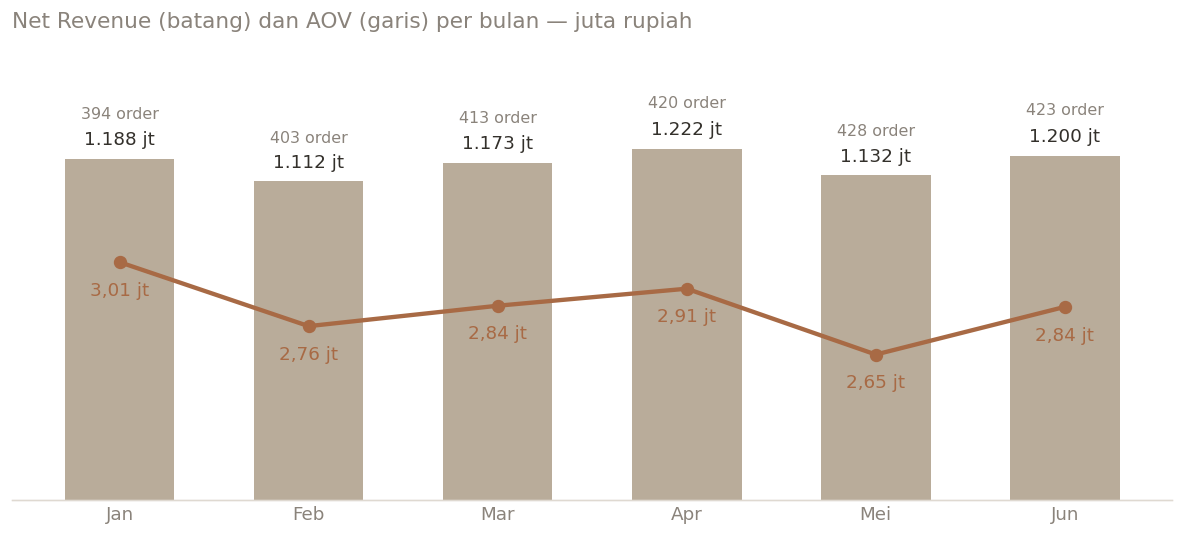

Net Revenue      : +1.0%
Completed Orders : +7.4%
Average Order Value: -5.9%

Order naik, nilai per order turun, revenue praktis diam.
Kenaikan jumlah order dibeli dengan memotong nilai tiap order.


In [ ]:
# Q1: revenue dipecah jadi komponennya. Revenue = jumlah order x nilai per order.
# Kalau revenue diam, ada dua kemungkinan: keduanya diam, atau keduanya bergerak
# berlawanan dan saling meniadakan. Dua kondisi itu butuh tindakan berbeda.
BULAN = ["Jan", "Feb", "Mar", "Apr", "Mei", "Jun"]

fig, ax = plt.subplots(figsize=(10, 4.6))
ax2 = ax.twinx()

bars = ax.bar(BULAN, kpi_bulanan.net_revenue / 1e6,
              color=PALET["stone"], width=0.58, zorder=2)
for b, rev, o in zip(bars, kpi_bulanan.net_revenue, kpi_bulanan.completed_orders):
    x = b.get_x() + b.get_width() / 2
    ax.text(x, rev/1e6*1.03, f"{id_num(rev/1e6)} jt", ha="center", va="bottom",
            fontsize=11, color=PALET["ink"])
    ax.text(x, rev/1e6*1.11, f"{int(o)} order", ha="center", va="bottom",
            fontsize=9.5, color="#8A837B")

ax2.plot(BULAN, kpi_bulanan.aov / 1e6, color=PALET["clay"],
         lw=2.6, marker="o", ms=7, zorder=3)
for x, v in zip(BULAN, kpi_bulanan.aov / 1e6):
    ax2.annotate(f"{id_num(v, 2)} jt", (x, v), textcoords="offset points",
                 xytext=(0, -20), ha="center", fontsize=11, color=PALET["clay"])

ax.set_ylim(0, kpi_bulanan.net_revenue.max()/1e6 * 1.28)
ax2.set_ylim(kpi_bulanan.aov.min()/1e6 * 0.78, kpi_bulanan.aov.max()/1e6 * 1.28)
rapikan(ax, "Net Revenue (batang) dan AOV (garis) per bulan \u2014 juta rupiah")
ax2.set_yticks([])
for s in ("top", "right", "left"):
    ax2.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

awal, akhir = kpi_bulanan.iloc[0], kpi_bulanan.iloc[-1]
print(f"Net Revenue      : {(akhir.net_revenue/awal.net_revenue-1)*100:+.1f}%")
print(f"Completed Orders : {(akhir.completed_orders/awal.completed_orders-1)*100:+.1f}%")
print(f"Average Order Value: {(akhir.aov/awal.aov-1)*100:+.1f}%")
print()
print("Order naik, nilai per order turun, revenue praktis diam.")
print("Kenaikan jumlah order dibeli dengan memotong nilai tiap order.")

### Temuan Q1

**Revenue enam bulan ini datar, bukan tumbuh.** Januari Rp 1.188 juta, Juni Rp 1.200 juta,
naik hanya 1,0%. Grafik batangnya memang terlihat rata, dan justru kerataan itu yang
membuat kondisinya terlihat sehat.

Tapi kerataan itu bukan karena semuanya diam. Ada dua gerakan besar yang berlawanan arah:

| Komponen | Jan | Jun | Perubahan |
|---|---|---|---|
| Completed Orders | 394 | 423 | **+7,4%** |
| Average Order Value | Rp 3,01 jt | Rp 2,84 jt | **−5,9%** |
| Net Revenue | Rp 1.188 jt | Rp 1.200 jt | +1,0% |

Jumlah order naik 7,4%, tetapi nilai per order turun 5,9%. Keduanya hampir saling
meniadakan, sehingga revenue nyaris tidak bergerak.

**Artinya perusahaan bekerja lebih keras untuk hasil yang sama.** Lebih banyak transaksi
diproses, lebih banyak barang dikirim, lebih banyak beban operasional tetapi uang yang
masuk tidak bertambah. Seluruh dinamika ini tidak terlihat kalau hanya melihat garis
revenue.

**Bulan yang menonjol.** April tertinggi, Rp 1.222 juta. Mei terendah, dan penyebabnya
terlihat jelas: AOV jatuh ke titik terendah Rp 2,65 juta meskipun jumlah ordernya justru
paling banyak, 428 order. Bulan itu volume tertinggi tetapi nilai per transaksi terendah.

Yang lebih layak diperhatikan justru Juni. Bukan karena revenue-nya, melainkan karena
cancellation rate melonjak jauh di atas kisaran lima bulan sebelumnya. Ini dibahas di
analisis discount rate dan cancellation rate per bulan.

**Pertanyaan lanjutan yang muncul dari sini:** kenapa nilai per order turun? Dua kandidat
penjelasan diuji terpisah apakah karena diskon yang makin besar (Q4), atau karena
komposisi customer bergeser (Q5).

#### Discount escalation per bulan

apakah kenaikan diskon dari bulan ke bulan diikuti kenaikan revenue.
Cancellation rate ikut ditampilkan karena lonjakan Juni terlihat di grafik yang sama.

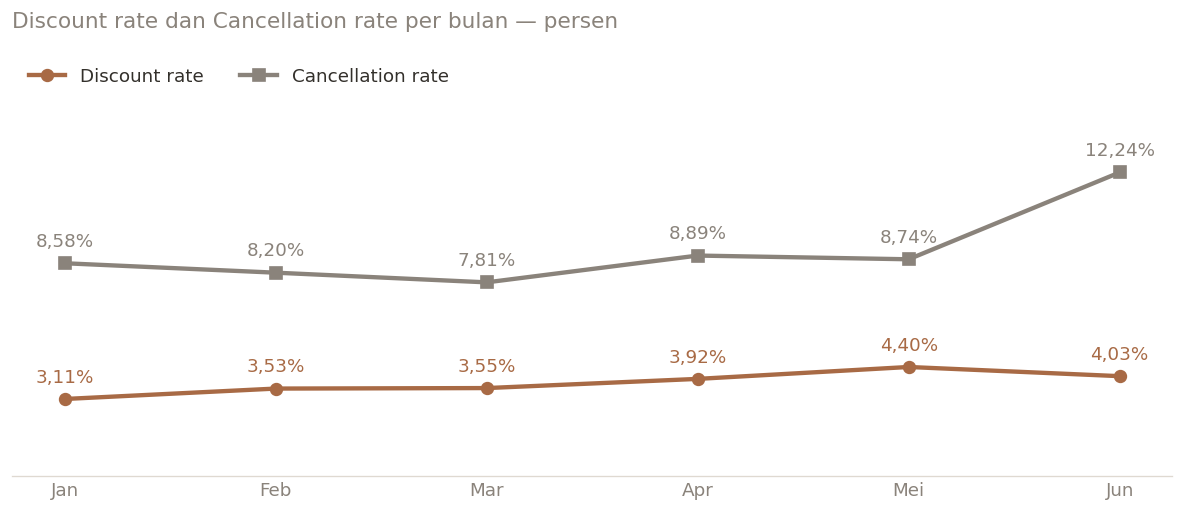

Discount rate : 3,11% ke 4,03%, puncak 4,40%
AOV           : -5.9%
Order         : +7.4%
Net Revenue   : +1.0%


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4.4))

ax.plot(BULAN, kpi_bulanan.discount_rate_pct, color=PALET["clay"], lw=2.6,
        marker="o", ms=7, label="Discount rate")
ax.plot(BULAN, kpi_bulanan.cancellation_rate_pct, color="#8A837B", lw=2.6,
        marker="s", ms=7, label="Cancellation rate")

for seri, warna in [(kpi_bulanan.discount_rate_pct, PALET["clay"]),
                    (kpi_bulanan.cancellation_rate_pct, "#8A837B")]:
    for x_, v in zip(BULAN, seri):
        ax.annotate(f"{id_num(v, 2)}%", (x_, v), textcoords="offset points",
                    xytext=(0, 10), ha="center", fontsize=11, color=warna)

rapikan(ax, "Discount rate dan Cancellation rate per bulan \u2014 persen")
ax.legend(frameon=False, ncol=2, loc="upper left")
ax.set_ylim(0, max(kpi_bulanan.cancellation_rate_pct.max(),
                   kpi_bulanan.discount_rate_pct.max()) * 1.40)
fig.tight_layout()
plt.show()

a_, z_ = kpi_bulanan.iloc[0], kpi_bulanan.iloc[-1]
print(f"Discount rate : {id_num(a_.discount_rate_pct,2)}% ke "
      f"{id_num(z_.discount_rate_pct,2)}%, puncak "
      f"{id_num(kpi_bulanan.discount_rate_pct.max(),2)}%")
print(f"AOV           : {(z_.aov/a_.aov-1)*100:+.1f}%")
print(f"Order         : {(z_.completed_orders/a_.completed_orders-1)*100:+.1f}%")
print(f"Net Revenue   : {(z_.net_revenue/a_.net_revenue-1)*100:+.1f}%")


### Temuan: discount escalation dan lonjakan pembatalan Juni

Grafik ini menjawab dua hal sekaligus, dan keduanya tidak terlihat di analisis kategori
maupun produk.

#### 1. Diskon naik terus, tetapi revenue tidak ikut naik

| | Jan | Jun | Puncak |
|---|---|---|---|
| Discount rate | 3,11% | 4,03% | **4,40%** (Mei) |

Diskon naik hampir sepertiga dari Januari ke puncaknya di Mei. Kalau ditaruh bersama
temuan Q1:

| Komponen | Perubahan Jan ke Jun |
|---|---|
| Discount rate | **naik** 3,11% ke 4,03% |
| Completed Orders | **+7,4%** |
| Average Order Value | **−5,9%** |
| Net Revenue | **+1,0%** |

Polanya jelas: menaikkan diskon berhasil menambah jumlah transaksi, tetapi tambahan itu
tidak cukup menutup nilai yang dilepas per transaksi. **Kenaikan order dibeli dengan
memotong nilai tiap order, dan hasil bersihnya nyaris nol.**

Ini tekanan margin. Revenue bertahan di angka yang sama, tetapi biaya untuk
mempertahankannya naik lebih banyak order diproses, lebih banyak diskon dikeluarkan.

**Perhatikan Mei.** Di bulan itu diskon mencapai puncak 4,40%, dan AOV justru jatuh ke
titik terendah Rp 2,65 juta meskipun jumlah ordernya paling banyak (428). Bulan itu contoh
paling jelas dari pola ini: volume tertinggi, nilai per transaksi terendah.

#### 2. Cancellation rate melonjak di Juni

| Jan | Feb | Mar | Apr | Mei | **Jun** |
|---|---|---|---|---|---|
| 8,58% | 8,20% | 7,81% | 8,89% | 8,74% | **12,24%** |

Lima bulan pertama stabil di kisaran 8%. Juni melonjak ke 12,24% naik sekitar 40% dari
rata-rata bulan sebelumnya, dan jauh di luar rentang normalnya.

Lonjakan setajam ini di satu bulan biasanya bukan pergeseran perilaku customer, melainkan
sesuatu yang berubah secara operasional. Karena itu perlu ditelusuri lebih lanjut, dan
pemeriksaan per channel serta per traffic source dilakukan di analisis berikutnya.

#### Batas kesimpulan

Hubungan antara diskon dan revenue di sini bersifat **asosiasi, bukan sebab akibat**. Data
ini tidak bisa membuktikan bahwa diskon yang menyebabkan AOV turun. Arah sebabnya bisa
terbalik: mungkin produk yang lambat terjual yang kemudian diberi diskon lebih besar.

Karena itu rekomendasi diskon dirancang sebagai **uji coba bertahap di satu kategori**
dengan kategori lain sebagai pembanding, bukan pemangkasan menyeluruh.

#### kpi_channel (Net Revenue, Completed Orders, AOV per channel)

Q2  Channel kontribusi revenue & AOV terbesar? Implikasi?

In [ ]:
# sales_channel konsisten dalam satu order, jadi aman dari fct_orders.
kpi_channel = duckdb.sql("""
    SELECT
        sales_channel,
        SUM(net_revenue)         AS net_revenue,
        SUM(is_completed_order)  AS completed_orders,
        COUNT(*)                 AS total_orders
    FROM fct_orders
    GROUP BY sales_channel
    ORDER BY net_revenue DESC
""").df()

kpi_channel["aov"] = (kpi_channel.net_revenue / kpi_channel.completed_orders).round(0)
kpi_channel["net_rev_share_pct"] = (kpi_channel.net_revenue / kpi_channel.net_revenue.sum() * 100).round(1)

kpi_channel

,sales_channel,net_revenue,completed_orders,total_orders,aov,net_rev_share_pct
0,Website,4.112854e+09,1436.0,1598,2864104.0,58.5
1,Marketplace,2.913981e+09,1045.0,1132,2788499.0,41.5


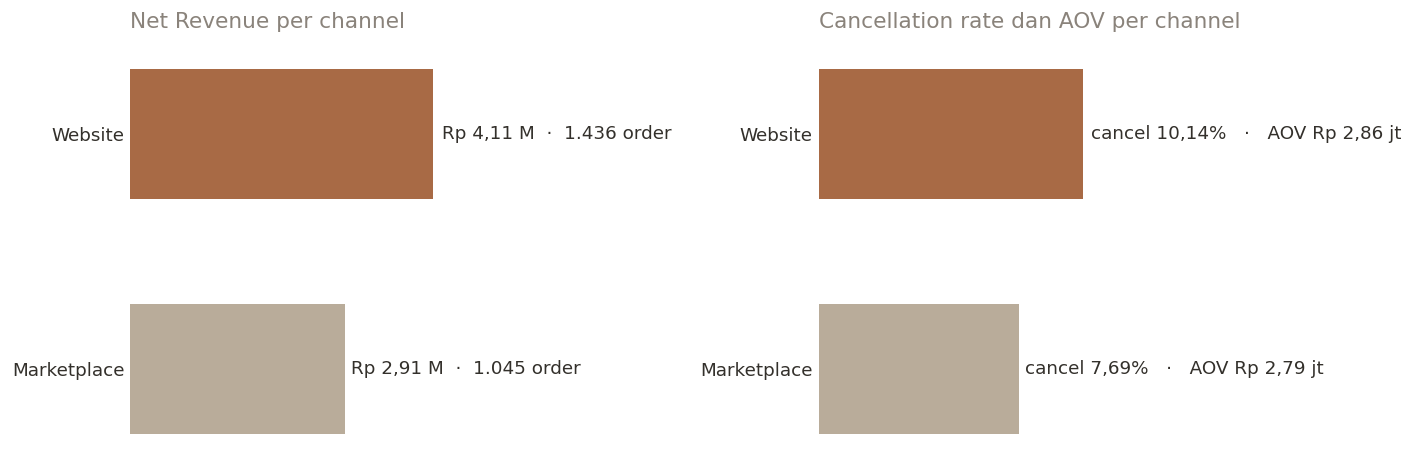

In [ ]:
kpi_channel["cancel_rate_pct"] = (
    (kpi_channel.total_orders - kpi_channel.completed_orders)
    / kpi_channel.total_orders * 100).round(2)

kc = kpi_channel.sort_values("net_revenue")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.0))

b1 = axes[0].barh(kc.sales_channel, kc.net_revenue / 1e9,
                  color=[WARNA[c] for c in kc.sales_channel], height=0.55)
for b, v, o in zip(b1, kc.net_revenue, kc.completed_orders):
    axes[0].text(v/1e9 * 1.03, b.get_y() + b.get_height()/2,
                 f"{rp(v, 'M')}  \u00b7  {id_num(o)} order",
                 va="center", fontsize=11, color=PALET["ink"])
rapikan(axes[0], "Net Revenue per channel", sumbu_y=True)
axes[0].set_xticks([]); axes[0].spines["bottom"].set_visible(False)
axes[0].set_xlim(0, kc.net_revenue.max()/1e9 * 1.75)

b2 = axes[1].barh(kc.sales_channel, kc.cancel_rate_pct,
                  color=[PALET["clay"] if v == kc.cancel_rate_pct.max()
                         else PALET["stone"] for v in kc.cancel_rate_pct], height=0.55)
for b, v, a in zip(b2, kc.cancel_rate_pct, kc.aov):
    axes[1].text(v * 1.03, b.get_y() + b.get_height()/2,
                 f"cancel {id_num(v, 2)}%   \u00b7   AOV {rp(a, 'jt')}",
                 va="center", fontsize=11, color=PALET["ink"])
rapikan(axes[1], "Cancellation rate dan AOV per channel", sumbu_y=True)
axes[1].set_xticks([]); axes[1].spines["bottom"].set_visible(False)
axes[1].set_xlim(0, kc.cancel_rate_pct.max() * 2.0)

fig.tight_layout()
plt.show()

### Temuan Q2 — dan satu keyakinan brief yang tidak terbukti

| Aspek | Website | Marketplace |
|---|---|---|
| Net Revenue | Rp 4,11 M (58,5%) | Rp 2,91 M (41,5%) |
| Completed Orders | 1.436 | 1.045 |
| Average Order Value | Rp 2,86 jt | Rp 2,79 jt |
| Cancellation rate | **10,14%** | **7,69%** |

#### Kontribusi terbesar ada di Website, tetapi itu soal volume

Website menyumbang 58,5% revenue. Namun begitu dilihat per transaksi, keunggulannya
hilang: AOV Website Rp 2,86 juta berbanding Marketplace Rp 2,79 juta, selisihnya hanya
2,7%.

Artinya Website unggul karena **memproses lebih banyak order** (1.436 berbanding 1.045),
bukan karena order-nya lebih bernilai.

#### Menguji keyakinan brief: karakteristik customer kedua channel

Brief menyebut Website dan Marketplace punya karakteristik customer yang berbeda. Kalimat
itu tidak bisa diuji apa adanya, jadi diterjemahkan dulu jadi dua hal yang bisa diukur:

1. Apakah nilai belanjanya berbeda? → AOV Rp 2,86 jt vs Rp 2,79 jt, **praktis sama**
2. Apakah komposisi customer barunya berbeda? → 53,2% vs 58,6%, **praktis sama**

Dari dua sisi yang bisa diukur, customer di kedua channel pada dasarnya serupa.
**Keyakinan ini tidak terbukti.**

#### Yang justru berbeda tidak ada di daftar dugaan

Pembeda nyatanya ada di **cancellation rate**: Website 10,14% berbanding Marketplace 7,69%.
Website membatalkan sekitar 1,3 kali lebih sering.

Jadi perbedaannya bukan pada siapa customer-nya, melainkan pada **kualitas order-nya**.

#### Implikasi yang bisa langsung dipakai

**Menambah volume di Marketplace tidak akan menurunkan kualitas order.** Nilai order-nya
setara sementara tingkat pembatalannya justru lebih rendah, dan volumenya masih 27% di
bawah Website. Ada ruang tumbuh di sana.

**Website perlu diperiksa dari sisi proses, bukan dari sisi customer.** Karena
customer-nya tidak berbeda, penyebab pembatalan lebih mungkin ada di alur checkout,
metode pembayaran, atau ketersediaan stok. Pemeriksaan lebih rinci dilakukan di analisis
cancellation rate per traffic source.

#### Catatan

Rekomendasi memperluas Marketplace ini belum memperhitungkan biaya akuisisi di sana,
karena data belanja pemasaran tidak tersedia. Marketplace

#### kpi_kategori (revenue + unit)

Q3  Kategori terbaik & terlemah? Mengapa?  

In [ ]:
# Kategori ada di level baris (satu order bisa lintas kategori), jadi WAJIB
# dari fct_order_lines. units_sold ditambahkan supaya kategori dibandingkan
# lewat volume, bukan hanya revenue: Handbags menang revenue karena harga tinggi.
kpi_kategori = duckdb.sql("""
    SELECT
        category,
        SUM(net_revenue) AS net_revenue,
        COUNT(DISTINCT CASE WHEN order_status = 'Completed'
                            THEN order_id END)     AS completed_orders,
        SUM(CASE WHEN order_status = 'Completed'
                 THEN quantity ELSE 0 END)         AS units_sold
    FROM fct_order_lines
    GROUP BY category
    ORDER BY net_revenue DESC
""").df()

kpi_kategori["net_rev_share_pct"]  = (kpi_kategori.net_revenue / kpi_kategori.net_revenue.sum() * 100).round(1)
kpi_kategori["unit_share_pct"]     = (kpi_kategori.units_sold / kpi_kategori.units_sold.sum() * 100).round(1)
kpi_kategori["avg_price_per_unit"] = (kpi_kategori.net_revenue / kpi_kategori.units_sold).round(0)

kpi_kategori

,category,net_revenue,completed_orders,units_sold,net_rev_share_pct,unit_share_pct,avg_price_per_unit
0,Handbags,2.988388e+09,640,1102.0,42.5,16.6,2711786.0
1,Shoes,2.146329e+09,942,1714.0,30.5,25.8,1252234.0
2,Ready-to-Wear,8.842510e+08,758,1401.0,12.6,21.1,631157.0
3,Accessories,5.582480e+08,810,1485.0,7.9,22.4,375925.0
4,Small Leather Goods,4.496190e+08,535,931.0,6.4,14.0,482942.0


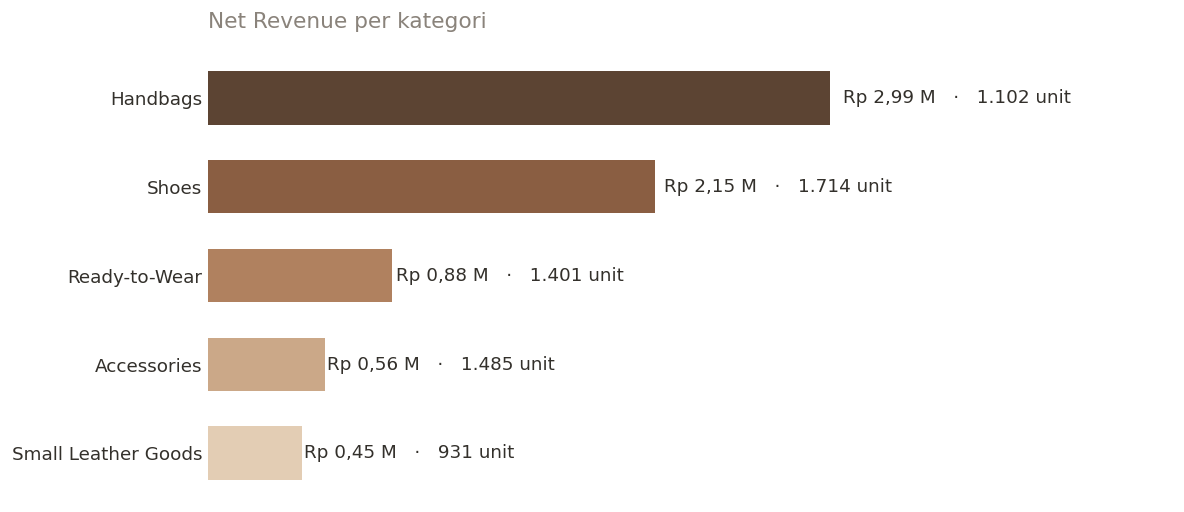

In [ ]:
kk = kpi_kategori.sort_values("net_revenue")   # urut menaik agar bar terbesar di atas

fig, ax = plt.subplots(figsize=(10, 4.4))
bars = ax.barh(kk.category, kk.net_revenue / 1e9,
               color=[WARNA_KAT[c] for c in kk.category], height=0.6)
for b, v, u in zip(bars, kk.net_revenue, kk.units_sold):
    ax.text(v/1e9 * 1.02, b.get_y() + b.get_height()/2,
            f"{rp(v, 'M')}   \u00b7   {id_num(u)} unit",
            va="center", fontsize=11, color=PALET["ink"])

rapikan(ax, "Net Revenue per kategori", sumbu_y=True)
ax.set_xticks([]); ax.spines["bottom"].set_visible(False)
ax.set_xlim(0, kk.net_revenue.max()/1e9 * 1.55)
fig.tight_layout()
plt.show()

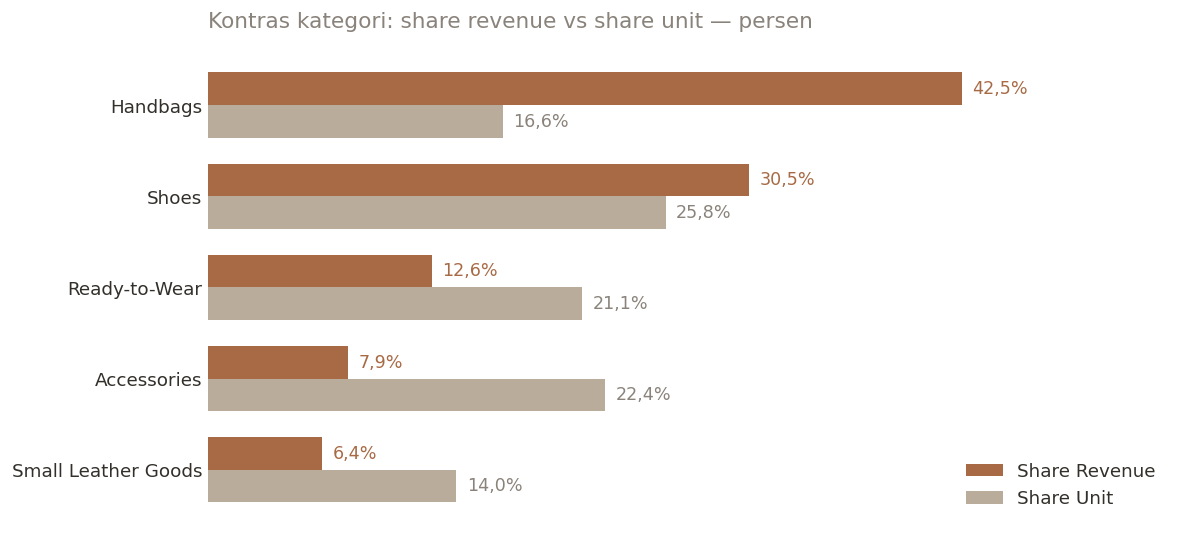

Handbags: 42,5% revenue dari hanya 16,6% unit.
Kategori terlemah bukan yang paling sedikit terjual, melainkan yang
banyak terjual tetapi nilainya kecil.


In [ ]:
# Membandingkan kategori lewat revenue saja menyesatkan, karena harga satuan
# berbeda jauh. Setelah dinormalkan dengan volume, kategori yang menang
# revenue ternyata menang di harga, bukan di jumlah barang terjual.
kk2 = kpi_kategori.sort_values("net_rev_share_pct")
y = np.arange(len(kk2))
tinggi = 0.36

fig, ax = plt.subplots(figsize=(10, 4.6))
b1 = ax.barh(y + tinggi/2, kk2.net_rev_share_pct, height=tinggi,
             color=PALET["clay"], label="Share Revenue")
b2 = ax.barh(y - tinggi/2, kk2.unit_share_pct, height=tinggi,
             color=PALET["stone"], label="Share Unit")

for b, v in zip(b1, kk2.net_rev_share_pct):
    ax.text(v + 0.6, b.get_y() + b.get_height()/2, f"{id_num(v, 1)}%",
            va="center", fontsize=10.5, color=PALET["clay"])
for b, v in zip(b2, kk2.unit_share_pct):
    ax.text(v + 0.6, b.get_y() + b.get_height()/2, f"{id_num(v, 1)}%",
            va="center", fontsize=10.5, color="#8A837B")

ax.set_yticks(y); ax.set_yticklabels(kk2.category)
rapikan(ax, "Kontras kategori: share revenue vs share unit \u2014 persen", sumbu_y=True)
ax.set_xticks([]); ax.spines["bottom"].set_visible(False)
ax.set_xlim(0, max(kk2.net_rev_share_pct.max(), kk2.unit_share_pct.max()) * 1.28)
ax.legend(frameon=False, loc="lower right")
fig.tight_layout()
plt.show()

atas = kpi_kategori.iloc[0]
print(f"{atas.category}: {id_num(atas.net_rev_share_pct,1)}% revenue "
      f"dari hanya {id_num(atas.unit_share_pct,1)}% unit.")
print("Kategori terlemah bukan yang paling sedikit terjual, melainkan yang")
print("banyak terjual tetapi nilainya kecil.")

### Temuan Q3

| Kategori | Share revenue | Share unit | Selisih | Harga rata-rata per unit |
|---|---|---|---|---|
| Handbags | **42,5%** | **16,6%** | +25,9 | Rp 2,71 jt |
| Shoes | 30,5% | 25,8% | +4,7 | Rp 1,25 jt |
| Ready-to-Wear | 12,6% | 21,1% | **−8,5** | Rp 631 rb |
| Accessories | **7,9%** | **22,4%** | **−14,5** | Rp 376 rb |
| Small Leather Goods | 6,4% | 14,0% | −7,6 | Rp 483 rb |

Cara membaca chart ini sederhana. Kalau batang atas (revenue) lebih panjang dari batang
bawah (unit), kategori itu menghasilkan lebih banyak uang daripada porsi barang yang
dikeluarkannya. Kalau terbalik, sebaliknya.

#### Kategori terbaik: Handbags

Handbags menghasilkan **42,5% revenue hanya dari 16,6% unit**, rasionya 2,6 banding 1. Ini
satu-satunya kategori dengan selisih besar ke arah positif.

Penyebabnya ada di kolom terakhir: harga rata-rata per unit Rp 2,71 juta, dua kali lipat
Shoes dan tujuh kali lipat Accessories.

Jadi Handbags menang **bukan karena laku keras**, melainkan karena tiap penjualan bernilai
besar. Shoes sebenarnya menjual lebih banyak unit, tetapi revenue-nya tetap di bawah.

#### Kategori terlemah: Accessories

Accessories persis kebalikannya: **22,4% unit hanya menghasilkan 7,9% revenue**. Selisih
minus 14,5 poin, terlebar di antara semua kategori.

Yang penting disadari, ini **bukan kategori yang sepi peminat**. Justru porsi unitnya
terbesar kedua setelah Shoes. Barangnya laku, tapi nilainya kecil.

Ready-to-Wear punya pola yang sama meski lebih ringan: 21,1% unit menghasilkan 12,6%
revenue.

#### Kenapa ini mengubah pertanyaannya

Kalau hanya melihat revenue, kesimpulannya "Accessories dan Small Leather Goods paling
kecil, kurangi perhatian ke sana". Setelah dinormalkan, gambarannya berbeda.

Accessories dan Ready-to-Wear bersama-sama menyerap **43,5% dari seluruh unit terjual**
tetapi hanya mengembalikan **20,5% revenue**. Artinya keduanya menyerap porsi besar beban
operasional, mulai dari stok yang dikelola, barang yang dikemas, order yang dikirim,
sampai potensi retur, dengan pengembalian yang tidak sebanding.

Jadi pertanyaan yang lebih berguna bagi Sales Manager bukan "kategori mana yang
revenue-nya kecil", melainkan **"kategori mana yang menyerap banyak sumber daya tetapi
mengembalikan sedikit"**. Jawabannya Accessories dan Ready-to-Wear.

#### Batas kesimpulan

Analisis ini berdiri di atas revenue, bukan profitabilitas. Tanpa data biaya pokok, ada
kemungkinan Accessories bermargin jauh lebih tinggi sehingga kontribusi labanya tidak
seburuk yang terlihat di sini. Barang bernilai kecil juga sering berfungsi sebagai pintu
masuk customer baru, dan efek itu tidak terukur dari data yang tersedia.

Akar masalah Ready-to-Wear dibedah lebih jauh di Q6, karena penyebabnya ternyata bukan
harga melainkan struktur asortimen.

### analisis_diskon

Q4  Apakah diskon lebih besar = revenue lebih tinggi?  

In [ ]:
# Q4: apakah diskon lebih besar selalu menghasilkan revenue lebih tinggi?
# discount_rate = total diskon / gross_sales (khusus Completed) per kategori.
analisis_diskon = duckdb.sql("""
    SELECT
        category,
        SUM(gross_sales) AS gross_sales,
        SUM(CASE WHEN order_status = 'Completed'
                 THEN discount_amount ELSE 0 END)  AS total_discount,
        SUM(CASE WHEN order_status = 'Completed'
                 THEN gross_sales ELSE 0 END)      AS gross_completed,
        SUM(net_revenue) AS net_revenue
    FROM fct_order_lines
    GROUP BY category
""").df()

analisis_diskon["discount_rate_pct"] = (analisis_diskon.total_discount / analisis_diskon.gross_completed * 100).round(2)
analisis_diskon = analisis_diskon.sort_values("discount_rate_pct", ascending=False).reset_index(drop=True)

# Arah asosiasi di level produk (BUKAN sebab-akibat): korelasi discount_rate vs net_revenue.
# Padanan pandas: prod_disc['disc_rate'].corr(prod_disc['net_revenue'])
prod_disc = duckdb.sql("""
    SELECT
        product_id,
        SUM(net_revenue) AS net_revenue,
        SUM(CASE WHEN order_status = 'Completed' THEN discount_amount ELSE 0 END) AS disc,
        SUM(CASE WHEN order_status = 'Completed' THEN gross_sales ELSE 0 END)     AS gross_completed
    FROM fct_order_lines
    GROUP BY product_id
    HAVING gross_completed > 0
""").df()
prod_disc["disc_rate"] = prod_disc.disc / prod_disc.gross_completed
korelasi = prod_disc["disc_rate"].corr(prod_disc["net_revenue"])
print(f"Korelasi discount_rate vs net_revenue (level produk): {korelasi:+.3f}")

analisis_diskon

Korelasi discount_rate vs net_revenue (level produk): -0.228


,category,gross_sales,total_discount,gross_completed,net_revenue,discount_rate_pct
0,Shoes,2.507999e+09,139262000.0,2.285591e+09,2.146329e+09,6.09
1,Ready-to-Wear,1.044256e+09,49578000.0,9.338290e+08,8.842510e+08,5.31
2,Accessories,6.339940e+08,19666000.0,5.779140e+08,5.582480e+08,3.40
3,Small Leather Goods,5.109860e+08,11587000.0,4.612060e+08,4.496190e+08,2.51
4,Handbags,3.337552e+09,54147000.0,3.042535e+09,2.988388e+09,1.78


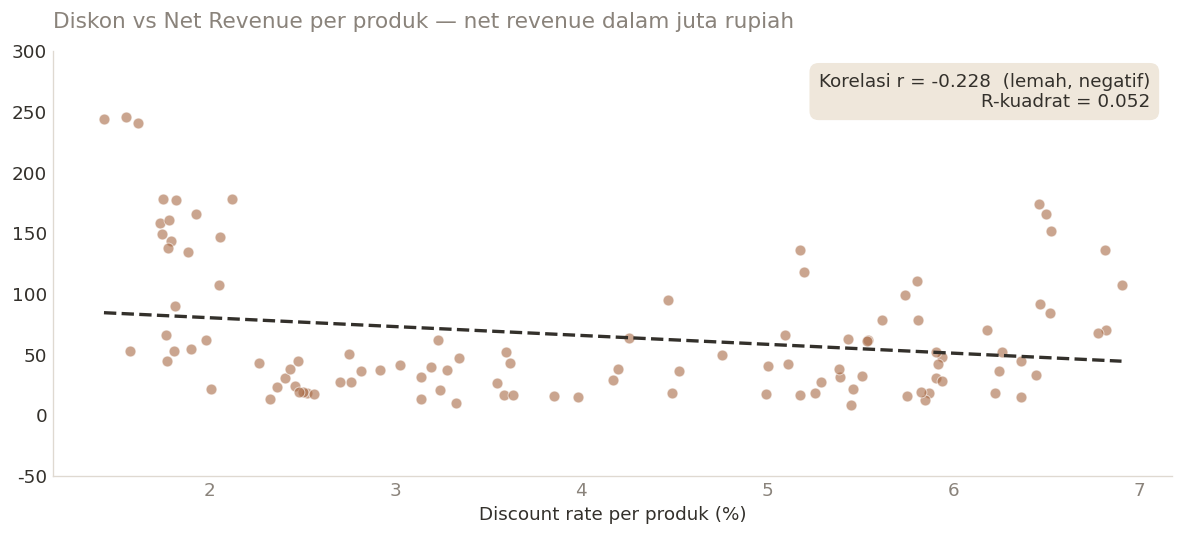

In [ ]:
# Scatter Q4: tiap titik satu produk. Kalau garis tren menurun, artinya diskon
# lebih besar TIDAK menghasilkan revenue lebih tinggi. prod_disc dan korelasi
# sudah dihitung di sel tabel analisis_diskon di atas.
x = prod_disc.disc_rate * 100
y = prod_disc.net_revenue
m, b = np.polyfit(x, y, 1)              # garis tren linear
xs = np.array([x.min(), x.max()])

fig, ax = plt.subplots(figsize=(10, 4.6))
ax.scatter(x, y / 1e6, s=42, color=PALET["clay"], alpha=0.6,
           edgecolors="white", linewidths=0.6, zorder=3)
ax.plot(xs, (m*xs + b) / 1e6, color=PALET["ink"], lw=2, ls="--", zorder=4)

arah = "negatif" if korelasi < 0 else "positif"
kuat = "lemah" if abs(korelasi) < 0.3 else ("sedang" if abs(korelasi) < 0.6 else "kuat")
ax.text(0.98, 0.95, f"Korelasi r = {korelasi:+.3f}  ({kuat}, {arah})\n"
                    f"R-kuadrat = {korelasi**2:.3f}",
        transform=ax.transAxes, ha="right", va="top", fontsize=11,
        color=PALET["ink"],
        bbox=dict(boxstyle="round,pad=0.5", facecolor=PALET["linen"], edgecolor="none"))

ax.set_xlabel("Discount rate per produk (%)")
rapikan(ax, "Diskon vs Net Revenue per produk \u2014 net revenue dalam juta rupiah",
        sumbu_y=True)
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels([id_num(v) for v in ax.get_yticks()])
ax.spines["left"].set_visible(True)
fig.tight_layout()
plt.show()


### Temuan Q4

**Jawabannya tidak, dan arahnya justru berlawanan.**

Diuji di tiga tingkat, dari yang paling kasar ke yang paling halus.

#### Tingkat 1: per kategori

| Kategori | Discount rate | Share revenue |
|---|---|---|
| Shoes | **6,09%** | 30,5% |
| Ready-to-Wear | **5,31%** | 12,6% |
| Accessories | 3,40% | 7,9% |
| Small Leather Goods | 2,51% | 6,4% |
| Handbags | **1,78%** | **42,5%** |

Tabel ini diurutkan dari diskon terbesar. Kalau diskon mendorong revenue, kolom kanan
seharusnya ikut menurun dari atas ke bawah. Yang terjadi justru sebaliknya.

Dua kategori dengan diskon terbesar, Shoes 6,09% dan Ready-to-Wear 5,31%, bukan penghasil
revenue tertinggi. Handbags dengan diskon terkecil 1,78% justru memimpin dengan selisih
jauh.

Selisihnya juga besar. Shoes menerima diskon **3,4 kali lipat** Handbags dalam bentuk
persentase, dan dalam rupiah Rp 139 juta berbanding Rp 54 juta, meskipun gross sales
Handbags justru lebih tinggi.

#### Tingkat 2: per produk

Korelasi discount rate dan net revenue di level produk: **minus 0,228**.

Dihitung di level produk, bukan kategori, karena kategori hanya punya lima titik data.
Korelasi dari lima titik tidak berarti banyak, satu kategori yang menyimpang bisa
membalik hasilnya.

Tandanya negatif, sejalan dengan temuan di tingkat kategori. Tetapi kekuatannya lemah:
R-kuadrat 0,052, artinya diskon hanya menjelaskan sekitar 5% variasi revenue antar produk.
Sisanya dijelaskan hal lain yang tidak masuk perhitungan ini, seperti harga satuan,
kategori, atau popularitas merek.

**Karena itu korelasi ini bukan bukti utama.** Ia dipakai sebagai pemeriksaan tambahan.
Yang penting bukan besar angkanya, melainkan tandanya. Kalau tandanya positif, kesimpulan
di tingkat kategori jadi meragukan. Karena tandanya negatif, keduanya searah.

#### Tingkat 3: per bulan

Ini yang paling menentukan, dan sudah dibahas di analisis discount escalation. Discount
rate naik dari 3,11% ke puncak 4,40%, sementara AOV turun 5,9% dan net revenue hanya naik
1,0%.

Kenaikan diskon diikuti kenaikan jumlah order, tetapi tidak diikuti kenaikan revenue.
Diskon berhasil menambah transaksi, tetapi tambahannya tidak cukup menutup nilai yang
dilepas per transaksi.

#### Batas kesimpulan yang penting

**Arah sebabnya bisa terbalik.** Sangat mungkin produk yang lambat terjual yang kemudian
diberi diskon lebih besar, bukan diskon yang membuat produk tidak laku. Data ini tidak
bisa membedakan keduanya.

Perhatikan juga sebaran titik di scatter plot. Titiknya berserak, bukan membentuk garis
rapi. Garis trennya memang menurun, tetapi kemiringannya landai dan banyak produk
berdiskon rendah yang revenue-nya juga rendah. Ini gambaran visual dari R-kuadrat 0,052.

Karena itu klaimnya ditulis sebagai **asosiasi**, bukan sebab akibat, dan rekomendasinya
dirancang sebagai **uji coba bertahap di satu kategori** dengan kategori lain sebagai
pembanding, bukan pemangkasan diskon menyeluruh.

Tanpa data biaya pokok, analisis ini juga belum bisa menilai apakah diskon di kategori
tertentu masih menguntungkan dari sisi margin, meskipun kontribusi revenue-nya kecil.

### kpi_customer_type (New vs Existing vs Unknown)

Q5  Perbedaan perilaku new vs existing customers dari sisi revenue dan frekuensi order?

In [ ]:
import numpy as np

# customer_type konsisten dalam satu order, jadi dari fct_orders.
# Baris Unknown ber-customer_id NULL, jadi n_customers = 0 dan metrik
# per-customer sengaja dibiarkan NaN (bukan dipaksa jadi angka).
kpi_customer_type = duckdb.sql("""
    SELECT
        customer_type,
        SUM(net_revenue)             AS net_revenue,
        SUM(is_completed_order)      AS completed_orders,
        COUNT(DISTINCT customer_id)  AS n_customers
    FROM fct_orders
    GROUP BY customer_type
    ORDER BY net_revenue DESC
""").df()

n_cust = kpi_customer_type.n_customers.replace(0, np.nan)   # hindari bagi nol untuk Unknown
kpi_customer_type["net_rev_share_pct"]   = (kpi_customer_type.net_revenue / kpi_customer_type.net_revenue.sum() * 100).round(1)
kpi_customer_type["orders_per_customer"] = (kpi_customer_type.completed_orders / n_cust).round(2)
kpi_customer_type["rev_per_customer"]    = (kpi_customer_type.net_revenue / n_cust).round(0)

kpi_customer_type

,customer_type,net_revenue,completed_orders,n_customers,net_rev_share_pct,orders_per_customer,rev_per_customer
0,New,3.896112e+09,1372.0,321,55.4,4.27,12137421.0
1,Existing,3.019380e+09,1067.0,587,43.0,1.82,5143749.0
2,Unknown,1.113425e+08,42.0,0,1.6,NaN,NaN


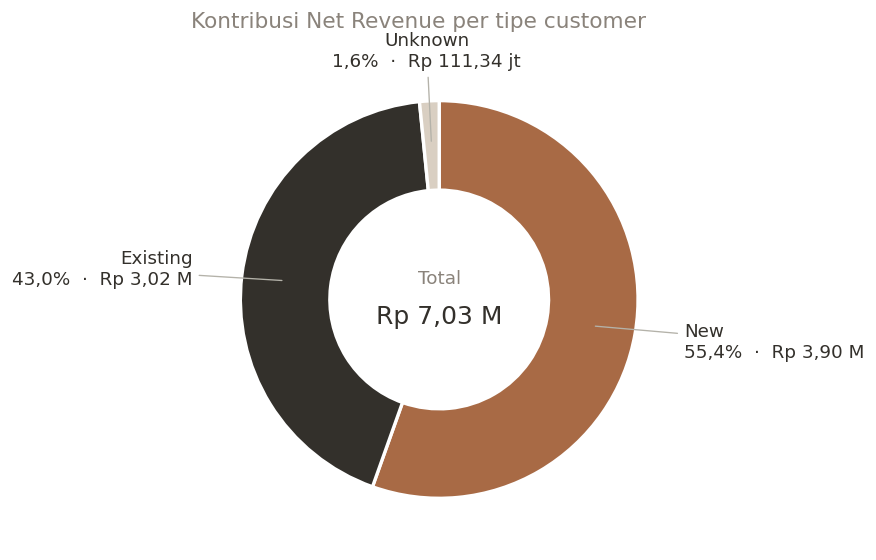

In [ ]:
# Donut kontribusi revenue per tipe customer (snapshot seluruh periode).
urut = ["New", "Existing", "Unknown"]
kc2 = kpi_customer_type.set_index("customer_type").loc[urut].reset_index()
total = kc2.net_revenue.sum()

fig, ax = plt.subplots(figsize=(7.5, 4.8))
wedges, _ = ax.pie(
    kc2.net_revenue,
    colors=[WARNA.get(t, PALET["stone"]) for t in kc2.customer_type],
    startangle=90, counterclock=False,
    wedgeprops=dict(width=0.45, edgecolor="white", linewidth=2))

for w, tipe, val, pct in zip(wedges, kc2.customer_type, kc2.net_revenue,
                             kc2.net_rev_share_pct):
    sudut = np.deg2rad((w.theta1 + w.theta2) / 2)
    ax.annotate(f"{tipe}\n{id_num(pct, 1)}%  \u00b7  {rp(val)}",
                xy=(np.cos(sudut) * 0.78, np.sin(sudut) * 0.78),
                xytext=(np.cos(sudut) * 1.25, np.sin(sudut) * 1.25),
                ha="center" if abs(np.cos(sudut)) < 0.3
                   else ("left" if np.cos(sudut) > 0 else "right"),
                va="center", fontsize=11, color=PALET["ink"],
                arrowprops=dict(arrowstyle="-", color="#B4B2A9", lw=0.8))

ax.text(0, 0.08, "Total", ha="center", fontsize=11, color="#8A837B")
ax.text(0, -0.12, rp(total, "M"), ha="center", fontsize=15, color=PALET["ink"])
ax.set_title("Kontribusi Net Revenue per tipe customer", loc="left",
             color="#8A837B", pad=14)
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

Customer baru menyumbang **55,4%** revenue (Rp 3,90 M), customer lama **43,0%** (Rp 3,02 M),
sisanya 1,6% dari guest checkout yang tidak punya customer_id.

Tapi angka ini adalah **snapshot seluruh periode**, dan snapshot tidak bisa menjawab
pertanyaan "apakah kontribusi customer lama melemah". Untuk itu perlu dilihat pergerakannya
per bulan, dan itu yang dilakukan di chart berikutnya.

Bucket **Unknown ditampilkan terbuka**, tidak disembunyikan dan tidak dipaksa masuk salah
satu kelompok. Porsinya kecil, tetapi menyembunyikannya akan membuat total breakdown tidak
sama dengan KPI total, dan siapa pun yang merekonsiliasi angkanya akan bingung.

### tren_customer_type

In [ ]:
# Q5: uji klaim "kontribusi repeat customer melemah" pakai ANGKA ABSOLUT dan
# revenue per customer, BUKAN persen. Porsi Existing pasti turun secara matematis
# karena kolam New terus bertambah, jadi persen menyesatkan.
#
# PERBAIKAN denominator. Ada DUA hitungan customer aktif, dan keduanya dipakai
# untuk hal yang berbeda:
#
#   active_customers            = customer yang punya order apa pun di bulan itu,
#                                 termasuk yang ordernya batal.
#                                 Dipakai untuk cerita "berapa orang yang datang".
#
#   active_customers_completed  = customer yang punya order Completed.
#                                 WAJIB dipakai sebagai penyebut rev_per_customer,
#                                 karena net_revenue juga hanya dari order Completed.
#
# Kalau penyebut rasio memakai angka pertama, pembilang dan penyebutnya lolos
# saringan berbeda, dan bisa muncul jumlah customer melebihi jumlah order.
tren_customer_type = duckdb.sql("""
    SELECT
        bulan,
        customer_type,
        SUM(net_revenue)             AS net_revenue,
        SUM(is_completed_order)      AS completed_orders,
        COUNT(DISTINCT customer_id)  AS active_customers,
        COUNT(DISTINCT CASE WHEN is_completed_order = 1
                            THEN customer_id END) AS active_customers_completed
    FROM fct_orders
    WHERE customer_type IN ('New', 'Existing')
    GROUP BY bulan, customer_type
    ORDER BY customer_type, bulan
""").df()

# Rasio memakai penyebut yang sejalan dengan pembilangnya.
tren_customer_type["rev_per_customer"] = (
    tren_customer_type.net_revenue / tren_customer_type.active_customers_completed).round(0)
tren_customer_type["orders_per_customer"] = (
    tren_customer_type.completed_orders / tren_customer_type.active_customers_completed).round(2)

# Uji kewajaran yang sebelumnya tidak ada: jumlah orang tidak mungkin melebihi
# jumlah order kalau pembilang dan penyebutnya lolos saringan yang sama.
assert (tren_customer_type.active_customers_completed
        <= tren_customer_type.completed_orders).all(), \
    "Penyebut belum sejalan: jumlah customer melebihi jumlah order Completed"
print("Uji kesejalanan pembilang-penyebut: LOLOS\n")

# pivot cepat: revenue Existing absolut per bulan (inti jawaban Q5)
display(tren_customer_type.pivot(index="bulan", columns="customer_type", values="net_revenue"))
tren_customer_type

Uji kesejalanan pembilang-penyebut: LOLOS



customer_type,Existing,New
bulan,,
2026-01,670998000.0,501754500.0
2026-02,568374000.0,506278000.0
2026-03,580916500.0,582393500.0
2026-04,501000000.0,706671000.0
2026-05,347351000.0,772729500.0
2026-06,350741000.0,826285500.0


,bulan,customer_type,net_revenue,completed_orders,active_customers,active_customers_completed,rev_per_customer,orders_per_customer
0,2026-01,Existing,670998000.0,220.0,209,189,3550254.0,1.16
1,2026-02,Existing,568374000.0,212.0,196,179,3175274.0,1.18
2,2026-03,Existing,580916500.0,209.0,196,184,3157155.0,1.14
3,2026-04,Existing,501000000.0,175.0,176,160,3131250.0,1.09
4,2026-05,Existing,347351000.0,130.0,129,122,2847139.0,1.07
5,2026-06,Existing,350741000.0,121.0,128,112,3131616.0,1.08
6,2026-01,New,501754500.0,170.0,144,135,3716700.0,1.26
7,2026-02,New,506278000.0,178.0,149,142,3565338.0,1.25
8,2026-03,New,582393500.0,198.0,154,146,3988997.0,1.36
9,2026-04,New,706671000.0,239.0,166,156,4529942.0,1.53


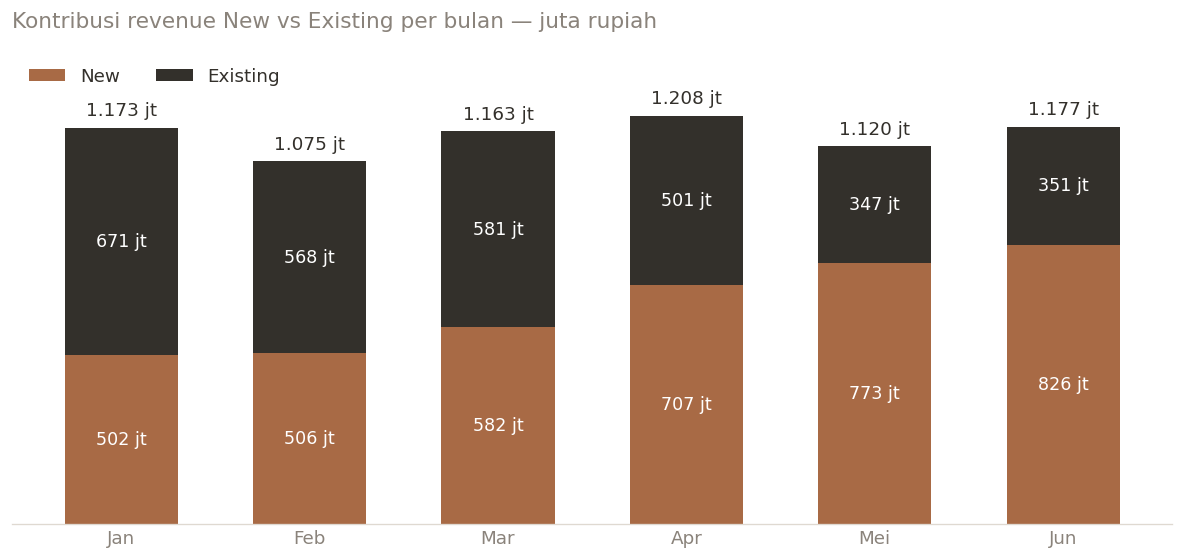

Revenue customer baru : +64.7%
Revenue customer lama : -47.7%


In [ ]:
# Kontribusi revenue New vs Existing per bulan, ditumpuk supaya total tiap
# bulan tetap terbaca sekaligus komposisinya.
piv = (tren_customer_type
       .pivot(index="bulan", columns="customer_type", values="net_revenue")
       .fillna(0))

fig, ax = plt.subplots(figsize=(10, 4.8))
bawah = np.zeros(len(piv))
for tipe in ["New", "Existing"]:
    v = piv[tipe].values / 1e6
    ax.bar(BULAN, v, bottom=bawah, color=WARNA[tipe], width=0.6, label=tipe)
    for i, (b, tinggi) in enumerate(zip(bawah, v)):
        ax.text(i, b + tinggi/2, f"{id_num(tinggi)} jt", ha="center", va="center",
                fontsize=10.5, color="white")
    bawah = bawah + v

for i, t in enumerate(bawah):
    ax.text(i, t * 1.02, f"{id_num(t)} jt", ha="center", va="bottom",
            fontsize=11, color=PALET["ink"])

rapikan(ax, "Kontribusi revenue New vs Existing per bulan \u2014 juta rupiah")
ax.set_ylim(0, bawah.max() * 1.16)
ax.legend(frameon=False, ncol=2, loc="upper left")
fig.tight_layout()
plt.show()

nw = tren_customer_type[tren_customer_type.customer_type == "New"].sort_values("bulan")
ex_ = tren_customer_type[tren_customer_type.customer_type == "Existing"].sort_values("bulan")
print(f"Revenue customer baru : {(nw.net_revenue.iloc[-1]/nw.net_revenue.iloc[0]-1)*100:+.1f}%")
print(f"Revenue customer lama : {(ex_.net_revenue.iloc[-1]/ex_.net_revenue.iloc[0]-1)*100:+.1f}%")


Inilah temuan utama seluruh analisis ini.

| | Januari | Juni | Perubahan |
|---|---|---|---|
| Customer baru | Rp 502 jt | Rp 826 jt | **+64,7%** |
| Customer lama | Rp 671 jt | Rp 351 jt | **−47,7%** |
| Total | Rp 1.173 jt | Rp 1.177 jt | +0,3% |

Perhatikan komposisi tiap batang. Pada Januari, bagian atas (customer lama) lebih besar
daripada bagian bawah. Pada Juni, posisinya berbalik total.

Kenaikan Rp 324 juta dari customer baru **hampir persis menutup** penurunan Rp 320 juta dari
customer lama. Keduanya bergerak besar dan berlawanan arah, sehingga totalnya nyaris tidak
bergerak.

**Jadi kestabilan revenue yang terlihat di Q1 itu semu.** Bukan karena semuanya diam,
melainkan karena dua masalah besar kebetulan saling meniadakan.

Konsekuensinya: pertumbuhan saat ini bergantung pada akuisisi terus-menerus. Begitu laju
akuisisi melambat, revenue akan langsung turun karena tidak ada penopang dari basis lama.

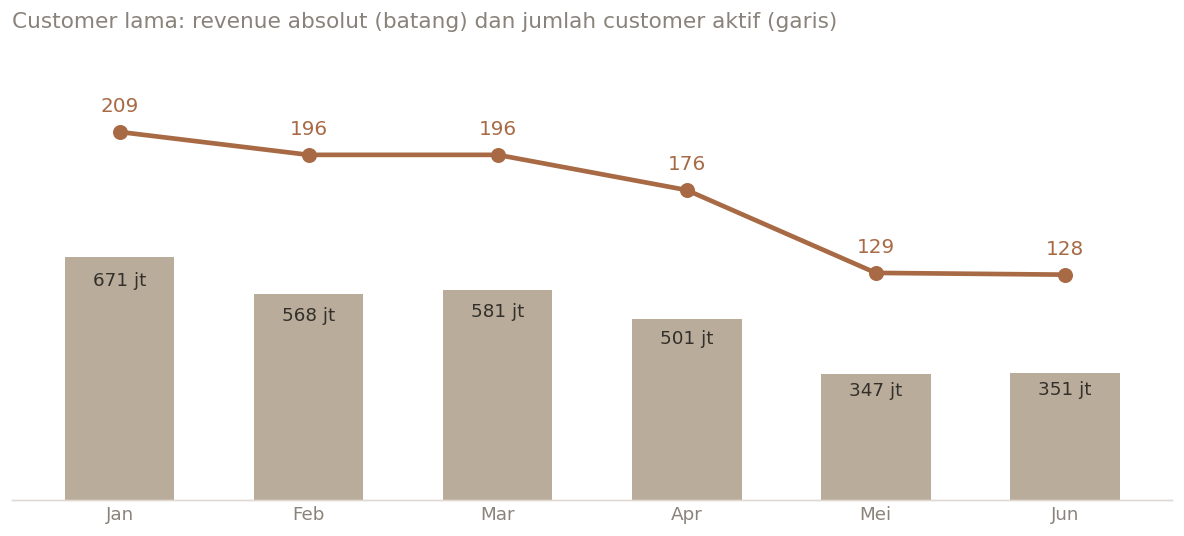

Ketiga komponen menurun, tetapi tidak sama besar.
Komponen dengan penurunan terbesar itulah yang perlu ditangani lebih dulu.



,Komponen customer lama,Januari,Juni,Perubahan
0,Jumlah orang aktif,209,128,-38.8%
1,Belanja per orang,"Rp 3,55 jt","Rp 3,13 jt",-11.8%
2,Frekuensi order,"1,16","1,08",-6.9%
3,Total revenue,"Rp 671,00 jt","Rp 350,74 jt",-47.7%


In [ ]:
# Dekomposisi Q5: revenue satu segmen = jumlah orang x frekuensi x nilai order.
# Kalau revenue turun, minimal satu dari tiga komponen itu turun. Memeriksa
# ketiganya penting karena masing-masing menuntut tindakan yang berbeda.
ex = tren_customer_type[tren_customer_type.customer_type == "Existing"].sort_values("bulan")

fig, ax = plt.subplots(figsize=(10, 4.6))
ax2 = ax.twinx()

bars = ax.bar(BULAN, ex.net_revenue / 1e6, color=PALET["stone"], width=0.58, zorder=2)
# Label revenue ditaruh DI DALAM batang supaya tidak bertabrakan dengan garis.
for b, v in zip(bars, ex.net_revenue / 1e6):
    ax.text(b.get_x() + b.get_width()/2, v * 0.94, f"{id_num(v)} jt",
            ha="center", va="top", fontsize=11, color=PALET["ink"])

ax2.plot(BULAN, ex.active_customers, color=PALET["clay"],
         lw=2.8, marker="o", ms=8, zorder=3)
for x_, v in zip(BULAN, ex.active_customers):
    ax2.annotate(f"{v:.0f}", (x_, v), textcoords="offset points",
                 xytext=(0, 12), ha="center", fontsize=12, color=PALET["clay"])

ax.set_ylim(0, (ex.net_revenue/1e6).max() * 1.85)
ax2.set_ylim(0, ex.active_customers.max() * 1.22)
rapikan(ax, "Customer lama: revenue absolut (batang) dan jumlah customer aktif (garis)")
ax2.set_yticks([])
for s in ("top", "right", "left"):
    ax2.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

a, z = ex.iloc[0], ex.iloc[-1]
def delta(x0, x1):
    return f"{(x1/x0-1)*100:+.1f}%"

dekomposisi = pd.DataFrame([
    ["Jumlah orang aktif", f"{a.active_customers:.0f}", f"{z.active_customers:.0f}",
     delta(a.active_customers, z.active_customers)],
    ["Belanja per orang", rp(a.rev_per_customer), rp(z.rev_per_customer),
     delta(a.rev_per_customer, z.rev_per_customer)],
    ["Frekuensi order", id_num(a.orders_per_customer, 2), id_num(z.orders_per_customer, 2),
     delta(a.orders_per_customer, z.orders_per_customer)],
    ["Total revenue", rp(a.net_revenue), rp(z.net_revenue),
     delta(a.net_revenue, z.net_revenue)],
], columns=["Komponen customer lama", "Januari", "Juni", "Perubahan"])

print("Ketiga komponen menurun, tetapi tidak sama besar.")
print("Komponen dengan penurunan terbesar itulah yang perlu ditangani lebih dulu.\n")
display(dekomposisi)

### Temuan Q5

Revenue satu segmen adalah hasil perkalian tiga hal: berapa orang yang aktif, seberapa
sering mereka belanja, dan berapa nilai sekali belanja. Kalau revenue turun, minimal satu
dari tiga itu pasti turun.

| Komponen customer lama | Januari | Juni | Perubahan |
|---|---|---|---|
| **Jumlah orang aktif** | 209 | 128 | **−38,8%** |
| Belanja per orang | Rp 3,55 jt | Rp 3,13 jt | −11,8% |
| Frekuensi order | 1,16 | 1,08 | −6,9% |
| Total revenue | Rp 671 jt | Rp 351 jt | −47,7% |

**Ketiga komponen menurun**, jadi tidak tepat menyebut nilai customer lama tidak berubah.
Belanja per orang turun 11,8% dan frekuensi turun 6,9%.

Tetapi penurunan jumlah orang jauh lebih besar: **38,8%, lebih dari tiga kali lipat**
penurunan belanja per orang. Grafik di atas menunjukkannya dengan jelas, garis customer
aktif menurun tajam sementara batang revenue mengikuti pola yang sama.

**Masalah utamanya kehadiran, bukan daya beli.** Customer lama tidak jadi lebih pelit
secara berarti, mereka hanya tidak datang lagi.

#### Kenapa perbedaan ini menentukan program

Kalau yang bermasalah daya beli, jawabannya penawaran, bundling, atau penyesuaian harga.
Karena yang bermasalah kehadiran, jawabannya **reaktivasi**, dan itu jauh lebih murah
daripada akuisisi customer baru.

Ukuran keberhasilan programnya pun berbeda. Yang perlu dikejar adalah **jumlah customer
lama aktif per bulan kembali mendekati 200**, bukan kenaikan nilai transaksi, karena nilai
transaksi memang bukan sumber masalahnya.

#### Catatan metode

Pengujian memakai **angka absolut**, bukan porsi kontribusi. Porsi customer lama pasti
turun secara matematis begitu jumlah customer baru bertambah, meskipun revenue mereka tidak
berubah sama sekali. Dengan angka absolut, penurunannya nyata: Rp 671 juta menjadi Rp 351
juta.

Penyebut `rev_per_customer` memakai `active_customers_completed`, yaitu customer yang punya
order Completed, sejalan dengan pembilangnya yang juga hanya dari order Completed. Uji
kesejalanan sudah dijalankan dan lolos.

Sementara kolom `active_customers` (209 ke 128) dipakai untuk cerita kehadiran, karena
customer yang datang lalu ordernya batal tetap datang, dan itu bagian dari sinyal retensi.

#### Satu hal yang perlu diakui

Frekuensi order customer baru terlihat lebih tinggi (1,63 di Juni berbanding 1,08). Tetapi
sebagian selisih itu bawaan definisi, bukan murni perbedaan perilaku. Customer masuk
kelompok New justru **karena** berbelanja di periode ini, sementara kelompok Existing
mencakup siapa pun yang pernah berbelanja sebelumnya, termasuk yang sudah lama tidak aktif.

Karena itu klaim utama di atas tidak bersandar pada perbandingan antar kelompok, melainkan
pada **tren di dalam kelompok Existing sendiri**, yang tidak terkena efek definisi ini.

###kpi_produk

Q6  Top 10 & Bottom 10 produk berdasarkan revenue?  

In [ ]:
# GROUP BY product_id (jebakan #5: ada 1 product_name dipakai 2 product_id).
# bulan_aktif dihitung dari launch_date (max rilis 2026-02-16) supaya produk
# yang baru sebentar dijual tidak dinilai buruk hanya karena masih baru.
kpi_produk = duckdb.sql("""
    SELECT
        product_id,
        ANY_VALUE(product_name) AS product_name,
        ANY_VALUE(category)     AS category,
        ANY_VALUE(launch_date)  AS launch_date,
        SUM(net_revenue) AS net_revenue,
        SUM(CASE WHEN order_status = 'Completed'
                 THEN quantity ELSE 0 END)         AS units_sold,
        COUNT(DISTINCT CASE WHEN order_status = 'Completed'
                            THEN order_id END)     AS completed_orders,
        -- jumlah bulan aktif dalam periode Jan-Jun 2026, minimal 1
        GREATEST(
            DATE_DIFF('month',
                GREATEST(ANY_VALUE(launch_date), DATE '2026-01-01'),
                DATE '2026-06-30') + 1,
            1
        ) AS bulan_aktif
    FROM fct_order_lines
    GROUP BY product_id
    ORDER BY net_revenue DESC
""").df()

kpi_produk["rev_per_bulan_aktif"] = (kpi_produk.net_revenue / kpi_produk.bulan_aktif).round(0)
kpi_produk["rank"] = range(1, len(kpi_produk) + 1)

top10    = kpi_produk.head(10)
bottom10 = kpi_produk.tail(10)
display(top10)
display(bottom10)

,product_id,product_name,category,launch_date,net_revenue,units_sold,completed_orders,bulan_aktif,rev_per_bulan_aktif,rank
0,PRD1008,Handbags ARCOVA 39,Handbags,2025-12-13,245296000.0,59.0,36,6,40882667.0,1
1,PRD1014,Handbags Elova 92,Handbags,2024-10-19,243631000.0,59.0,38,6,40605167.0,2
2,PRD1017,Handbags Elova 59,Handbags,2025-10-25,240725000.0,59.0,32,6,40120833.0,3
3,PRD1019,Handbags Cantera 65,Handbags,2025-08-05,178153000.0,54.0,36,6,29692167.0,4
4,PRD1001,Handbags Mirela 23,Handbags,2023-05-17,178140500.0,57.0,35,6,29690083.0,5
5,PRD1021,Handbags Mirela 30,Handbags,2023-09-04,177297500.0,69.0,42,6,29549583.0,6
6,PRD1072,Shoes Sybren 45,Shoes,2024-12-03,174163000.0,90.0,58,6,29027167.0,7
7,PRD1058,Shoes Arcova 83,Shoes,2024-11-13,165617000.0,97.0,50,6,27602833.0,8
8,PRD1011,Handbags Tesse 41,Handbags,2025-07-24,165273500.0,38.0,25,6,27545583.0,9
9,PRD1005,Handbags Cantera 58,Handbags,2023-03-17,160987500.0,48.0,30,6,26831250.0,10


,product_id,product_name,category,launch_date,net_revenue,units_sold,completed_orders,bulan_aktif,rev_per_bulan_aktif,rank
98,PRD1034,Ready-to-Wear Tesse 59,Ready-to-Wear,2022-05-01,16276000.0,48.0,32,6,2712667.0,99
99,PRD1045,Ready-to-Wear Norvik 42,Ready-to-Wear,2023-02-21,15302000.0,47.0,30,6,2550333.0,100
100,PRD1088,Accessories Arcova 48,Accessories,2023-05-13,15277500.0,98.0,58,6,2546250.0,101
101,PRD1085,Accessories Sybren 57,Accessories,2023-03-23,14434500.0,70.0,45,6,2405750.0,102
102,PRD1035,Ready-to-Wear Sybren 47,Ready-to-Wear,2025-11-27,14365000.0,33.0,21,6,2394167.0,103
103,PRD1080,Accessories luria 64,Accessories,2024-03-17,13474000.0,64.0,46,6,2245667.0,104
104,PRD1098,Small Leather Goods Norvik 57,Small Leather Goods,2023-05-14,13012000.0,60.0,38,6,2168667.0,105
105,PRD1028,Ready-to-Wear cantera 40,Ready-to-Wear,2022-03-06,11866000.0,49.0,30,6,1977667.0,106
106,PRD1084,Accessories Luria 40,Accessories,2023-02-13,9762500.0,82.0,54,6,1627083.0,107
107,PRD1041,Ready-to-Wear Mirela 26,Ready-to-Wear,2022-05-31,8366500.0,46.0,26,6,1394417.0,108


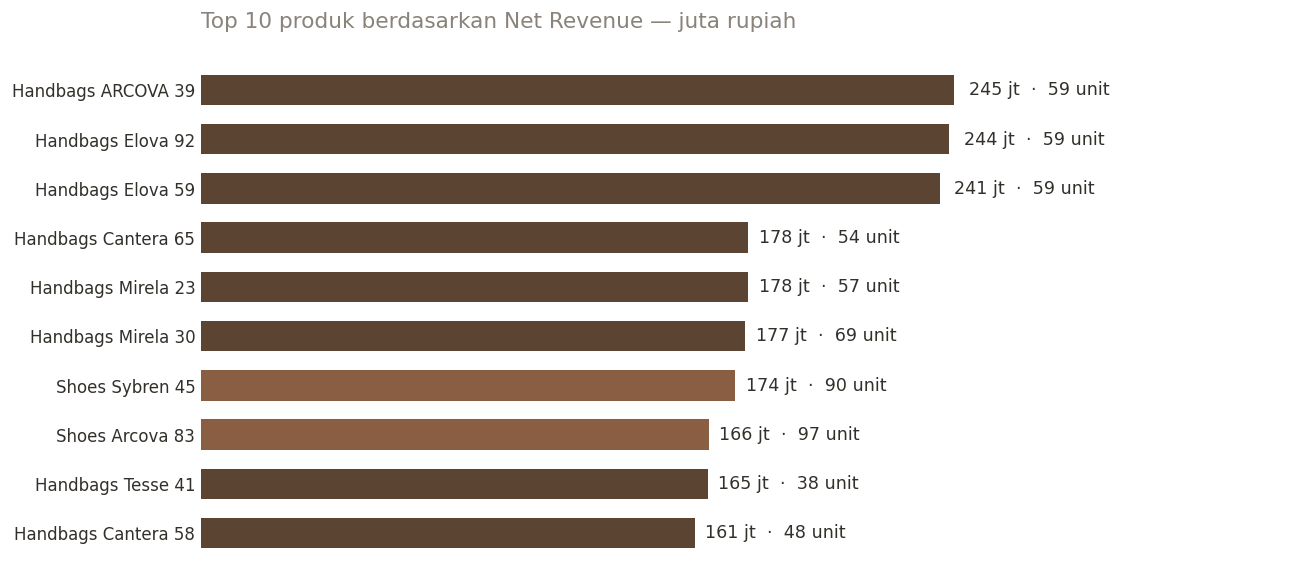

In [ ]:
t10 = top10.sort_values("net_revenue")   # top10 sudah didefinisikan di sel kpi_produk

fig, ax = plt.subplots(figsize=(11, 5.0))
bars = ax.barh(t10.product_name, t10.net_revenue / 1e6,
               color=[WARNA_KAT.get(c, "#888880") for c in t10.category], height=0.62)
for b, v, u in zip(bars, t10.net_revenue, t10.units_sold):
    ax.text(v/1e6 * 1.02, b.get_y() + b.get_height()/2,
            f"{id_num(v/1e6)} jt  \u00b7  {int(u)} unit",
            va="center", fontsize=10.5, color=PALET["ink"])

rapikan(ax, "Top 10 produk berdasarkan Net Revenue \u2014 juta rupiah", sumbu_y=True)
ax.set_xticks([]); ax.spines["bottom"].set_visible(False)
ax.set_xlim(0, (t10.net_revenue/1e6).max() * 1.45)
ax.tick_params(axis="y", labelsize=10)
fig.tight_layout()
plt.show()

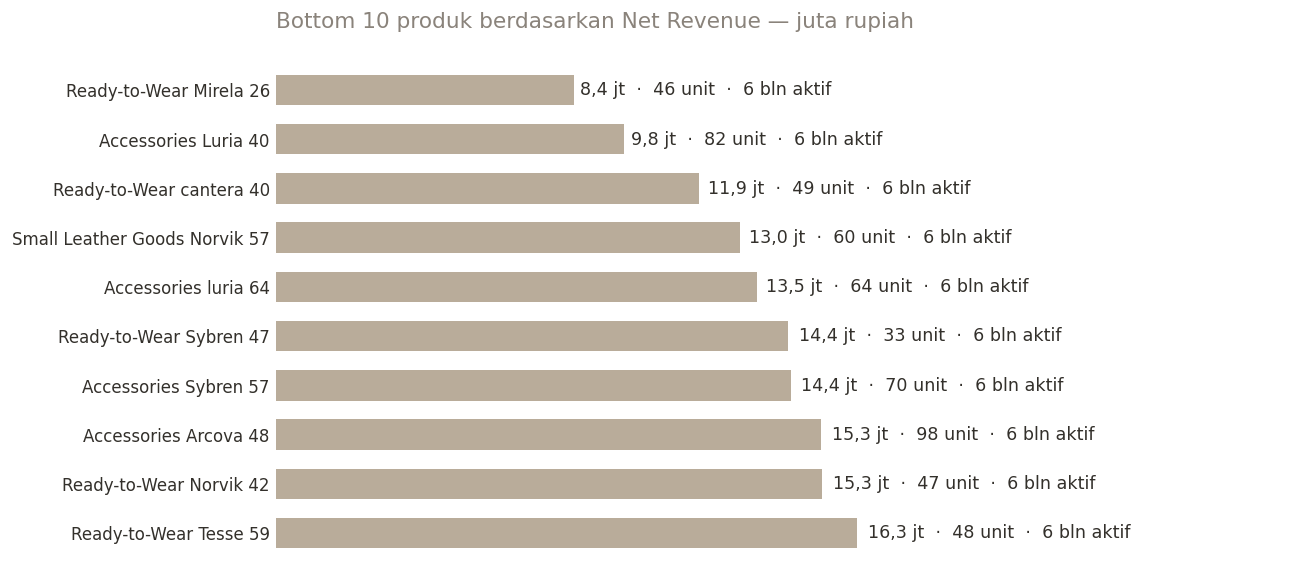

In [ ]:
b10 = bottom10.sort_values("net_revenue", ascending=False)

fig, ax = plt.subplots(figsize=(11, 5.0))
bars = ax.barh(b10.product_name, b10.net_revenue / 1e6,
               color=PALET["stone"], height=0.62)   # abu, dibedakan dari Top 10 yang clay
for b, v, u, m_ in zip(bars, b10.net_revenue, b10.units_sold, b10.bulan_aktif):
    ax.text(v/1e6 * 1.02, b.get_y() + b.get_height()/2,
            f"{id_num(v/1e6, 1)} jt  \u00b7  {int(u)} unit  \u00b7  {int(m_)} bln aktif",
            va="center", fontsize=10.5, color=PALET["ink"])

rapikan(ax, "Bottom 10 produk berdasarkan Net Revenue \u2014 juta rupiah", sumbu_y=True)
ax.set_xticks([]); ax.spines["bottom"].set_visible(False)
ax.set_xlim(0, (b10.net_revenue/1e6).max() * 1.75)
ax.tick_params(axis="y", labelsize=10)
fig.tight_layout()
plt.show()

### Temuan Q6

#### Revenue sangat terkonsentrasi

| | Kontribusi |
|---|---|
| Top 10 produk | **27,5%** dari total revenue |
| Bottom 10 produk | **1,9%** dari total revenue |

Sepuluh produk teratas menyumbang lebih dari seperempat revenue, sementara sepuluh produk
terbawah gabungan hanya 1,9%. Selisih per produknya bahkan lebih tajam: produk peringkat
satu menghasilkan Rp 245 juta, peringkat terakhir Rp 8,4 juta, terpaut hampir 30 kali
lipat.

#### Top 10 dikuasai Handbags, dan itu soal harga bukan volume

Delapan dari sepuluh produk teratas berasal dari Handbags. Ini konsisten dengan temuan Q3.

Buktinya ada di kolom unit. **Shoes Sybren 45 menjual 90 unit** tetapi revenue-nya Rp 174
juta, masih di bawah **Handbags ARCOVA 39 yang hanya terjual 59 unit** dengan revenue Rp
245 juta. Produk terbaik kita menang karena tiap penjualan bernilai besar, bukan karena
laku keras.

#### Bottom 10: kontrol launch_date yang wajib dijalankan

Sebelum menyimpulkan apa pun dari Bottom 10, `launch_date` diperiksa dulu. Produk yang baru
rilis dua bulan lalu wajar kalau revenue-nya kecil, dan itu bukan produk bermasalah.

**Hasilnya: seluruh Bottom 10 punya bulan_aktif = 6**, artinya sudah dijual penuh selama
periode analisis. Revenue rendahnya memang karena tidak laku, bukan karena baru rilis.

Tanpa pemeriksaan ini, rekomendasi pemangkasan bisa salah sasaran dan justru memotong
produk yang belum sempat diuji pasar.

#### Komposisi Bottom 10 menunjuk ke dua kategori

| Kategori | Jumlah produk di Bottom 10 | Total revenue |
|---|---|---|
| Ready-to-Wear | **5** | Rp 66,2 jt |
| Accessories | **4** | Rp 52,9 jt |
| Small Leather Goods | 1 | Rp 13,0 jt |

Sembilan dari sepuluh produk terlemah berasal dari dua kategori yang di Q3 sudah
teridentifikasi lemah. Ini bukan kebetulan, dan menunjukkan masalahnya bersifat kategori,
bukan produk per produk.

#### Akar masalah Ready-to-Wear: struktur asortimen, bukan harga

| Kategori | Jumlah SKU | Rata-rata revenue per produk |
|---|---|---|
| Handbags | 22 | **Rp 135,8 jt** |
| Shoes | 24 | Rp 89,4 jt |
| Ready-to-Wear | **28** | **Rp 31,6 jt** |
| Accessories | 18 | Rp 31,0 jt |
| Small Leather Goods | 16 | Rp 28,1 jt |

Ready-to-Wear punya **SKU terbanyak** (28 produk) tetapi **revenue per produk terkecil
ketiga** (Rp 31,6 juta). Bandingkan Handbags: SKU lebih sedikit (22) tetapi revenue per
produknya lebih dari empat kali lipat.

Artinya perhatian, stok, dan diskon tersebar ke terlalu banyak produk yang masing-masing
tidak laku.

**Ini sekaligus menjelaskan hal yang terlihat aneh di Q4:** kenapa Ready-to-Wear bisa
sekaligus mendapat diskon besar (5,31%) dan berperingkat rendah. Diskonnya tersebar ke 28
produk, sehingga tidak ada satu produk pun yang benar-benar terdorong.

#### Implikasi

Rekomendasinya bukan menaikkan harga atau menambah diskon, melainkan **rasionalisasi SKU**.
Pangkas produk Ready-to-Wear yang masuk peringkat terbawah, lalu alihkan perhatian dan
anggaran promosi ke produk yang tersisa.

Ukuran keberhasilannya: revenue rata-rata per produk Ready-to-Wear naik, bukan revenue
total kategori naik, karena pemangkasan SKU secara alami akan mengurangi revenue total
dalam jangka pendek.

#### Batas kesimpulan

Analisis ini tidak memperhitungkan peran sebuah produk di luar revenue langsungnya. Produk
Ready-to-Wear berharga rendah bisa saja berfungsi melengkapi tampilan koleksi atau menarik
customer yang akhirnya membeli kategori lain. Efek seperti itu tidak terukur dari data yang
tersedia, sehingga pemangkasan sebaiknya dilakukan bertahap dan dievaluasi.

### Analisis tambahan: cancellation rate per traffic source

Bukan bagian dari enam pertanyaan, tetapi muncul dari temuan Q1 dan Q2.

Lonjakan pembatalan di Juni sudah dipastikan merata di dua channel dan lima kategori,
yang menandakan penyebabnya lintas lini. Potongan yang belum dicoba adalah sumber trafik,
dan justru di situ selisihnya paling tajam.

Kalau perbedaannya besar, rekomendasi "audit checkout Website" bisa dipersempit jadi
"audit paid traffic" — jauh lebih mudah ditindaklanjuti.

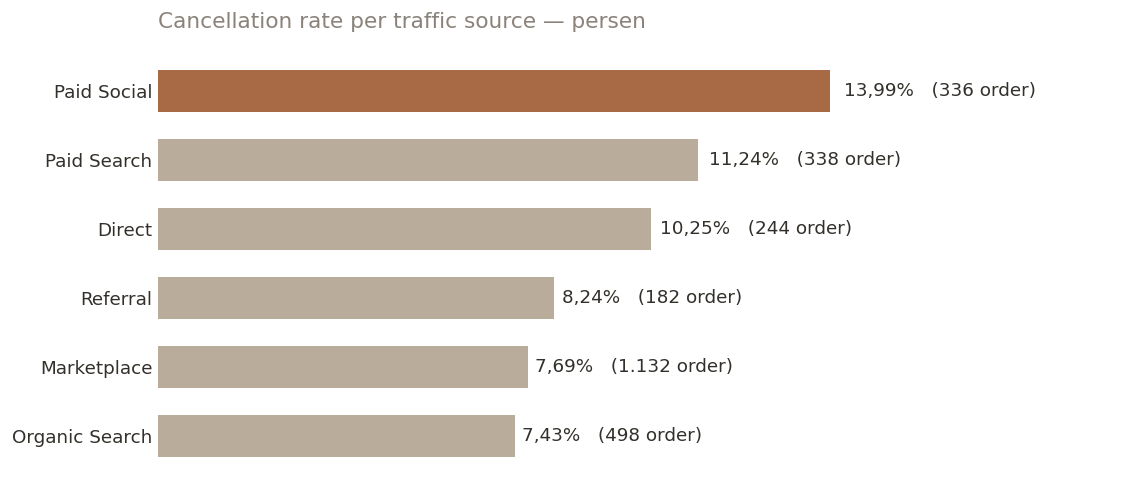

Tertinggi : Paid Social (13,99%)
Terendah  : Organic Search (7,43%)
Rasio     : 1.9x


In [ ]:
cancel_traffic = duckdb.sql("""
    SELECT
        traffic_source,
        COUNT(*)                     AS total_orders,
        SUM(is_cancelled_order)      AS cancelled_orders
    FROM fct_orders
    WHERE traffic_source IS NOT NULL
    GROUP BY traffic_source
""").df()
cancel_traffic["cancel_rate_pct"] = (
    cancel_traffic.cancelled_orders / cancel_traffic.total_orders * 100).round(2)

ct = cancel_traffic.sort_values("cancel_rate_pct")
puncak = ct.cancel_rate_pct.max()

fig, ax = plt.subplots(figsize=(9.5, 4.2))
bars = ax.barh(ct.traffic_source, ct.cancel_rate_pct,
               color=[PALET["clay"] if v >= puncak * 0.92 else PALET["stone"]
                      for v in ct.cancel_rate_pct], height=0.6)
for b, v, n in zip(bars, ct.cancel_rate_pct, ct.total_orders):
    ax.text(v * 1.02, b.get_y() + b.get_height()/2,
            f"{id_num(v, 2)}%   ({id_num(n)} order)",
            va="center", fontsize=11, color=PALET["ink"])

rapikan(ax, "Cancellation rate per traffic source \u2014 persen", sumbu_y=True)
ax.set_xticks([]); ax.spines["bottom"].set_visible(False)
ax.set_xlim(0, puncak * 1.42)
fig.tight_layout()
plt.show()

print(f"Tertinggi : {ct.iloc[-1].traffic_source} ({id_num(ct.iloc[-1].cancel_rate_pct,2)}%)")
print(f"Terendah  : {ct.iloc[0].traffic_source} ({id_num(ct.iloc[0].cancel_rate_pct,2)}%)")
print(f"Rasio     : {ct.iloc[-1].cancel_rate_pct/ct.iloc[0].cancel_rate_pct:.1f}x")

In [ ]:

ringkas_bottom = (bottom10.groupby("category")
    .agg(jumlah_produk=("product_id", "count"),
         total_revenue=("net_revenue", "sum"),
         min_bulan_aktif=("bulan_aktif", "min"))
    .sort_values("jumlah_produk", ascending=False))

share_bottom = bottom10.net_revenue.sum() / kpi_produk.net_revenue.sum() * 100
share_top    = top10.net_revenue.sum()    / kpi_produk.net_revenue.sum() * 100

print(f"Kontribusi Top 10    : {share_top:.1f}% dari total revenue")
print(f"Kontribusi Bottom 10 : {share_bottom:.1f}% dari total revenue")
print(f"Bulan aktif Bottom 10: {sorted(bottom10.bulan_aktif.unique())}  (6 = aktif penuh)")
display(ringkas_bottom)

rata_per_produk = (kpi_produk.groupby("category")
    .agg(jumlah_sku=("product_id", "count"),
         rata_revenue_per_produk=("net_revenue", "mean"))
    .sort_values("rata_revenue_per_produk", ascending=False)
    .round(0))
display(rata_per_produk)

Kontribusi Top 10    : 27.5% dari total revenue
Kontribusi Bottom 10 : 1.9% dari total revenue
Bulan aktif Bottom 10: [np.int64(6)]  (6 = aktif penuh)


,jumlah_produk,total_revenue,min_bulan_aktif
category,,,
Ready-to-Wear,5,66175500.0,6
Accessories,4,52948500.0,6
Small Leather Goods,1,13012000.0,6


,jumlah_sku,rata_revenue_per_produk
category,,
Handbags,22,135835818.0
Shoes,24,89430375.0
Ready-to-Wear,28,31580393.0
Accessories,18,31013778.0
Small Leather Goods,16,28101188.0


### Temuan tambahan: dari mana audit pembatalan sebaiknya dimulai

| Traffic source | Cancel rate | Jumlah order |
|---|---|---|
| **Paid Social** | **13,99%** | 336 |
| **Paid Search** | **11,24%** | 338 |
| Direct | 10,25% | 244 |
| Referral | 8,24% | 182 |
| Marketplace | 7,69% | 1.132 |
| Organic Search | 7,43% | 498 |

Selisih tertinggi ke terendah **1,9 kali lipat**, jauh lebih tajam dibanding potongan per
channel yang hanya 1,3 kali (Website 10,14% berbanding Marketplace 7,69%).

#### Polanya jelas: berbayar versus organik

Dua sumber trafik berbayar menempati dua posisi teratas, sementara Organic Search justru
paling rendah. Direct berada di tengah, dan itu masuk akal karena pengunjung yang mengetik
alamat langsung biasanya sudah punya niat beli.

Ini konsisten secara perilaku. Pengunjung dari iklan sering datang dengan niat beli yang
belum matang, terpicu oleh tampilan iklan, sehingga lebih mudah berubah pikiran sebelum
order selesai. Pengunjung organik datang karena mencari sendiri, jadi niatnya lebih kuat.

#### Kenapa ini mengubah rekomendasi

Rekomendasi awal "audit checkout Website" terlalu luas. Website memproses 1.598 order dari
berbagai sumber trafik, dan memeriksa seluruh alurnya akan menghabiskan waktu tim di
tempat yang belum tentu bermasalah.

Potongan per traffic source mempersempitnya jadi **audit alur dari trafik berbayar**, yang
jauh lebih mudah ditindaklanjuti. Yang perlu diperiksa antara lain kesesuaian antara janji
di iklan dan halaman tujuan, serta titik mana di checkout yang paling banyak ditinggalkan
oleh pengunjung dari kanal berbayar.

#### Batas kesimpulan

Analisis ini menunjukkan **di mana** pembatalan paling sering terjadi, bukan **kenapa**.
Tanpa data funnel dan tahapan checkout, penyebab pastinya belum bisa dipastikan.

Pembatalan yang tinggi di kanal berbayar juga tidak otomatis berarti kanal itu tidak layak.
Kanal berbayar mungkin tetap menguntungkan jika volume dan nilai order yang berhasil cukup
menutup biaya iklannya, tetapi penilaian itu butuh data belanja pemasaran yang tidak
tersedia di sini.

In [ ]:
# ================= EKSPOR KE EXCEL UNTUK TABLEAU =================
# Excel menyimpan tipe data asli (angka tetap angka, tanggal tetap tanggal),
# sehingga Tableau tidak perlu menebak dari teks. Ini menghindari masalah
# pemisah desimal yang membuat kolom terbaca null.

kolom = ["order_line_id","order_id","order_date","bulan","customer_id","customer_type",
         "sales_channel","traffic_source","payment_method","product_id","product_name",
         "category","brand","launch_date","quantity","unit_selling_price","discount_amount",
         "list_price","order_status","gross_sales","net_revenue","is_completed","is_cancelled"]

export = fct_order_lines[kolom].copy()

# 1. Kolom angka jadi integer. Semua nilai rupiah di dataset ini bilangan bulat,
#    jadi tidak ada informasi yang hilang saat dibulatkan.
kolom_angka = ["quantity","unit_selling_price","discount_amount","list_price",
               "gross_sales","net_revenue","is_completed","is_cancelled"]
for c in kolom_angka:
    export[c] = pd.to_numeric(export[c], errors="coerce").round(0).astype("int64")

# 2. Kolom tanggal jadi datetime asli, bukan teks
export["order_date"]  = pd.to_datetime(export["order_date"])
export["launch_date"] = pd.to_datetime(export["launch_date"])

# 3. Simpan
export.to_excel("fct_order_lines.xlsx", index=False, sheet_name="fct_order_lines")

# 4. Verifikasi sebelum diunduh
print("Baris        :", len(export))
print("Net Revenue  :", f"{export.net_revenue.sum():,}")      # harus 7,026,835,000
print("Completed    :", export.loc[export.order_status=="Completed","order_id"].nunique())  # harus 2481
display(export.dtypes.to_frame("tipe"))                        # angka harus int64, tanggal datetime64

# 5. Unduh
# from google.colab import files
# files.download("fct_order_lines.xlsx")

Baris        : 4598
Net Revenue  : 7,026,835,000
Completed    : 2481


,tipe
order_line_id,object
order_id,object
order_date,datetime64[us]
bulan,object
customer_id,object
customer_type,object
sales_channel,object
traffic_source,object
payment_method,object
product_id,object
